# House Sale Price Prediction Using Machine Learning

## Project Objective

The objective of this project is to build a complete machine-learning pipeline
that predicts the actual sale price of a residential property using its
structural, location, quality, condition, and sale-related features.

The project includes:

- Machine-learning introduction
- Exploratory Data Analysis
- Missing-value and duplicate analysis
- Outlier investigation
- Important visualizations
- Data preprocessing
- Linear Regression mathematics
- Model training
- Regression evaluation
- Actual versus predicted price analysis
- Residual analysis
- User-input house-price prediction
- A separate classification section for confusion matrix, accuracy, precision,
  recall, F1 score, and confidence probability

In [1]:
# Cell 2: Verify Selected Python Environment

import sys
print("Python version:", sys.version)
print("Python executable:", sys.executable)


Python version: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
Python executable: c:\Users\Hp\Desktop\Housing Price prediction\.venv\Scripts\python.exe


In [2]:
# Cell 3: Verify Dataset Files

from pathlib import Path

# Find the folder in which the notebook is currently running
current_folder = Path.cwd()

# If the notebook is running inside the "notebooks" folder,
# move one level upward to reach the main project folder
project_folder = (
    current_folder.parent
    if current_folder.name.lower() == "notebooks"
    else current_folder
)

# Create paths to the data folder and required files
data_folder = project_folder / "data"
train_file = data_folder / "train.csv"
description_file = data_folder / "data_description.txt"

# Display paths and verify whether the files exist
print("Current folder:", current_folder)
print("Project folder:", project_folder)
print("Data folder:", data_folder)
print("train.csv exists:", train_file.exists())
print("data_description.txt exists:", description_file.exists())

Current folder: c:\Users\Hp\Desktop\Housing Price prediction\notebooks
Project folder: c:\Users\Hp\Desktop\Housing Price prediction
Data folder: c:\Users\Hp\Desktop\Housing Price prediction\data
train.csv exists: True
data_description.txt exists: True


# Cell 4: Introduction to Machine Learning

Machine learning is a branch of artificial intelligence in which a computer
learns patterns from previous data and uses those patterns to make predictions
or decisions about new data.

In traditional programming, a programmer manually writes rules:

Data + Rules → Output

In machine learning, the model learns the rules from examples:

Historical Data + Correct Outputs → Learned Model

In this project, the historical data contains information about previously sold
houses. The model will learn the relationship between house characteristics and
their actual sale prices.

The input features may include:

- Living area
- Number of bedrooms
- Number of bathrooms
- Neighborhood
- Construction year
- Overall quality
- Garage capacity
- Basement area

The target variable is:

- `SalePrice`

After training, the model will receive the characteristics of a new house and
predict its possible sale price.

## Type of Machine Learning

This project uses supervised learning because the training dataset contains both:

- Input features describing each house
- The correct sale price of each house

## Regression Problem

House-price prediction is a regression problem because the model predicts a
continuous numerical value, such as:

- $150,000
- $275,500
- $410,000

A classification model would instead predict a category such as cheap, medium,
or expensive.

In [3]:
#Cell 5: Import Data-Analysis Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("ALL DATA-ANALYSIS LIBRARIES IMPORTED SUCCEUSSFULLY.")


ALL DATA-ANALYSIS LIBRARIES IMPORTED SUCCEUSSFULLY.


In [4]:
# Cell 6: Configure Visualization Display

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Visualization and display settings configured.")

Visualization and display settings configured.


In [5]:
# Cell 7: Load the Original Housing Dataset

housing_df = pd.read_csv(
    train_file,
    keep_default_na=False,
    na_values=["NA"]
)

print("Dataset loaded successfully.")
print("Number of rows:", housing_df.shape[0])
print("Number of columns:", housing_df.shape[1])

Dataset loaded successfully.
Number of rows: 1460
Number of columns: 81


In [6]:
#Cell 8: Preview the First Five Houses

housing_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
# Cell 9: Preview the Last Five Houses

housing_df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,None,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,None,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [8]:
#Cell 10: Display Random House Record

housing_df.sample(5, random_state=42)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
892,893,20,RL,70.0,8414,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,1Fam,1Story,6,8,1963,2003,Hip,CompShg,HdBoard,HdBoard,None,0.0,TA,TA,CBlock,TA,TA,No,GLQ,663,Unf,0,396,1059,GasA,TA,Y,SBrkr,1068,0,0,1068,0,1,1,0,3,1,TA,6,Typ,0,NaN,Attchd,1963.0,RFn,1,264,TA,TA,Y,192,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2006,WD,Normal,154500
1105,1106,60,RL,98.0,12256,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,1994,1995,Gable,CompShg,HdBoard,HdBoard,BrkFace,362.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1032,Unf,0,431,1463,GasA,Ex,Y,SBrkr,1500,1122,0,2622,1,0,2,1,3,1,Gd,9,Typ,2,TA,Attchd,1994.0,RFn,2,712,TA,TA,Y,186,32,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,325000
413,414,30,RM,56.0,8960,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1Story,5,6,1927,1950,Gable,CompShg,WdShing,Wd Shng,None,0.0,TA,TA,CBlock,TA,TA,No,Unf,0,Unf,0,1008,1008,GasA,Gd,Y,FuseA,1028,0,0,1028,0,0,1,0,2,1,TA,5,Typ,1,Gd,Detchd,1927.0,Unf,2,360,TA,TA,Y,0,0,130,0,0,0,NaN,NaN,NaN,0,3,2010,WD,Normal,115000
522,523,50,RM,50.0,5000,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Feedr,Norm,1Fam,1.5Fin,6,7,1947,1950,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,Gd,CBlock,TA,TA,No,ALQ,399,Unf,0,605,1004,GasA,Ex,Y,SBrkr,1004,660,0,1664,0,0,2,0,3,1,TA,7,Typ,2,Gd,Detchd,1950.0,Unf,2,420,TA,TA,Y,0,24,36,0,0,0,NaN,NaN,NaN,0,10,2006,WD,Normal,159000
1036,1037,20,RL,89.0,12898,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,Timber,Norm,Norm,1Fam,1Story,9,5,2007,2008,Hip,CompShg,VinylSd,VinylSd,Stone,70.0,Gd,TA,PConc,Ex,TA,Gd,GLQ,1022,Unf,0,598,1620,GasA,Ex,Y,SBrkr,1620,0,0,1620,1,0,2,0,2,1,Ex,6,Typ,1,Ex,Attchd,2008.0,Fin,3,912,TA,TA,Y,228,0,0,0,0,0,NaN,NaN,NaN,0,9,2009,WD,Normal,315500


In [9]:
# Cell 11: Confirm Dataset Dimensions

number_of_rows, number_of_columns = housing_df.shape

print("Number of house records:", number_of_rows)
print("Total number of columns:", number_of_columns)

Number of house records: 1460
Total number of columns: 81


In [10]:
#Cell 12: Identify Features, Target and Identifiers

identifier_column = "Id"
target_column = "SalePrice"

candidate_feature_column = [
    column
    for column in housing_df.columns
    if column not in [identifier_column, target_column]

]

print("Identifiers column:", identifier_column)
print("Target Column:", target_column)
print("Number of candidate input features:", len(candidate_feature_column))

Identifiers column: Id
Target Column: SalePrice
Number of candidate input features: 79


In [11]:
# Cell 13: Display All Column Names

for column_number, column_name in enumerate(housing_df.columns, start=1):
    print(f"{column_number}. {column_name}")

1. Id
2. MSSubClass
3. MSZoning
4. LotFrontage
5. LotArea
6. Street
7. Alley
8. LotShape
9. LandContour
10. Utilities
11. LotConfig
12. LandSlope
13. Neighborhood
14. Condition1
15. Condition2
16. BldgType
17. HouseStyle
18. OverallQual
19. OverallCond
20. YearBuilt
21. YearRemodAdd
22. RoofStyle
23. RoofMatl
24. Exterior1st
25. Exterior2nd
26. MasVnrType
27. MasVnrArea
28. ExterQual
29. ExterCond
30. Foundation
31. BsmtQual
32. BsmtCond
33. BsmtExposure
34. BsmtFinType1
35. BsmtFinSF1
36. BsmtFinType2
37. BsmtFinSF2
38. BsmtUnfSF
39. TotalBsmtSF
40. Heating
41. HeatingQC
42. CentralAir
43. Electrical
44. 1stFlrSF
45. 2ndFlrSF
46. LowQualFinSF
47. GrLivArea
48. BsmtFullBath
49. BsmtHalfBath
50. FullBath
51. HalfBath
52. BedroomAbvGr
53. KitchenAbvGr
54. KitchenQual
55. TotRmsAbvGrd
56. Functional
57. Fireplaces
58. FireplaceQu
59. GarageType
60. GarageYrBlt
61. GarageFinish
62. GarageCars
63. GarageArea
64. GarageQual
65. GarageCond
66. PavedDrive
67. WoodDeckSF
68. OpenPorchSF
69. Enc

In [12]:
# Cell 14: Inspect Dataset Information

housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

# Cell 15: Initial Dataset Structure Findings

The dataset contains 1,460 residential property records and 81 columns.

- Each row represents one sold property.
- `SalePrice` is the target variable that the model will predict.
- `Id` is a record identifier and is not a meaningful house characteristic.
- The remaining 79 columns are candidate input features.
- The dataset contains both numerical and categorical information.
- Some columns have fewer than 1,460 non-null values, indicating missing data.
- No cleaning or modification has been performed at this stage.

In [13]:
# Cell 16: Count Columns by Technical Data Type

data_type_counts = housing_df.dtypes.value_counts()

print("Number of columns by Pandas data type:")
print(data_type_counts)

Number of columns by Pandas data type:
str        43
int64      35
float64     3
Name: count, dtype: int64


In [14]:
# Cell 17: Separate Columns Using Pandas Data Types

technical_numerical_columns = housing_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

technical_categorical_columns = housing_df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Technically numerical columns:", len(technical_numerical_columns))
print("Technically categorical columns:", len(technical_categorical_columns))

Technically numerical columns: 38
Technically categorical columns: 43


C:\Users\Hp\AppData\Local\Temp\ipykernel_2992\435532686.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  technical_categorical_columns = housing_df.select_dtypes(


In [15]:
# Cell 18: Display Technically Numerical Columns

for column_number, column_name in enumerate(
    technical_numerical_columns,
    start=1
):
    print(f"{column_number}. {column_name}")

1. Id
2. MSSubClass
3. LotFrontage
4. LotArea
5. OverallQual
6. OverallCond
7. YearBuilt
8. YearRemodAdd
9. MasVnrArea
10. BsmtFinSF1
11. BsmtFinSF2
12. BsmtUnfSF
13. TotalBsmtSF
14. 1stFlrSF
15. 2ndFlrSF
16. LowQualFinSF
17. GrLivArea
18. BsmtFullBath
19. BsmtHalfBath
20. FullBath
21. HalfBath
22. BedroomAbvGr
23. KitchenAbvGr
24. TotRmsAbvGrd
25. Fireplaces
26. GarageYrBlt
27. GarageCars
28. GarageArea
29. WoodDeckSF
30. OpenPorchSF
31. EnclosedPorch
32. 3SsnPorch
33. ScreenPorch
34. PoolArea
35. MiscVal
36. MoSold
37. YrSold
38. SalePrice


In [16]:
# Cell 19: Review Important Numerically Stored Columns

semantic_review = pd.DataFrame(
    {
        "Column": [
            "MSSubClass",
            "MoSold",
            "OverallQual",
            "OverallCond",
            "YearBuilt",
            "YrSold",
        ],
        "Stored_Type": [
            str(housing_df["MSSubClass"].dtype),
            str(housing_df["MoSold"].dtype),
            str(housing_df["OverallQual"].dtype),
            str(housing_df["OverallCond"].dtype),
            str(housing_df["YearBuilt"].dtype),
            str(housing_df["YrSold"].dtype),
        ],
        "Real_Meaning": [
            "Dwelling type code",
            "Month of sale",
            "Ordered house quality score",
            "Ordered house condition score",
            "Construction year",
            "Sale year",
        ],
        "Semantic_Type": [
            "Nominal categorical",
            "Calendar categorical",
            "Ordinal numerical",
            "Ordinal numerical",
            "Numerical year",
            "Numerical year",
        ],
    }
)

semantic_review


,Column,Stored_Type,Real_Meaning,Semantic_Type
0,MSSubClass,int64,Dwelling type code,Nominal categorical
1,MoSold,int64,Month of sale,Calendar categorical
2,OverallQual,int64,Ordered house quality score,Ordinal numerical
3,OverallCond,int64,Ordered house condition score,Ordinal numerical
4,YearBuilt,int64,Construction year,Numerical year
5,YrSold,int64,Sale year,Numerical year


In [17]:
# Cell 20: Define Numerical and Categorical Feature Groups

identifier_column = "Id"
target_column = "SalePrice"

# Numerical codes that logically represent categories
numeric_but_categorical = [
    "MSSubClass",
    "MoSold",
]

# Object columns are categorical by default
categorical_feature_columns = (
    technical_categorical_columns
    + numeric_but_categorical
)

# Remove categorical codes, identifier, and target
# from the numerical feature list
numerical_feature_columns = [
    column
    for column in technical_numerical_columns
    if column not in (
        numeric_but_categorical
        + [identifier_column, target_column]
    )
]

print("Numerical input features:", len(numerical_feature_columns))
print("Categorical input features:", len(categorical_feature_columns))
print("Target column:", target_column)
print("Identifier column:", identifier_column)

Numerical input features: 34
Categorical input features: 45
Target column: SalePrice
Identifier column: Id


In [18]:
# Cell 21: Verify Feature Classification

classified_columns = (
    numerical_feature_columns
    + categorical_feature_columns
    + [identifier_column, target_column]
)

unclassified_columns = [
    column
    for column in housing_df.columns
    if column not in classified_columns
]

duplicated_classifications = [
    column
    for column in classified_columns
    if classified_columns.count(column) > 1
]

print("Total dataset columns:", housing_df.shape[1])
print("Total classified columns:", len(classified_columns))
print("Unclassified columns:", unclassified_columns)
print(
    "Columns assigned more than once:",
    sorted(set(duplicated_classifications))
)

Total dataset columns: 81
Total classified columns: 81
Unclassified columns: []
Columns assigned more than once: []


# Cell 23: Missing-Value Analysis

A missing value means that a value is unavailable or represented by a missing
marker in the dataset.

However, missing values do not always mean that data was accidentally omitted.

In this housing dataset, a missing value may mean:

1. The information was not recorded.
2. The house does not contain that feature.
3. The value is genuinely unknown.

For example:

- Missing `PoolQC` may mean that the house has no pool.
- Missing `GarageType` may mean that the house has no garage.
- Missing `LotFrontage` may mean that the frontage measurement is unknown.

Therefore, missing values must be investigated before deciding how to handle
them.

In [19]:
# Cell 24: Count Missing Values in Every Column

missing_value_counts = housing_df.isna().sum()

print(missing_value_counts)

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType          8
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [20]:
# Cell 25: Create Missing-Value Summary Table

missing_summary = pd.DataFrame(
    {
        "Missing_Count": housing_df.isna().sum(),
        "Missing_Percentage": (
            housing_df.isna().sum() / len(housing_df)
        ) * 100,
    }
)

# Keep only columns containing at least one missing value
missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
]

# Arrange columns from highest to lowest missing percentage
missing_summary = missing_summary.sort_values(
    by="Missing_Percentage",
    ascending=False
)

# Round percentages to two decimal places
missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Percentage"].round(2)
)

missing_summary

,Missing_Count,Missing_Percentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageCond,81,5.55
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [21]:
# Cell 26: Summarize Missing Values

columns_with_missing_values = missing_summary.shape[0]
total_missing_cells = housing_df.isna().sum().sum()
total_dataset_cells = housing_df.shape[0] * housing_df.shape[1]

overall_missing_percentage = (
    total_missing_cells / total_dataset_cells
) * 100

print(
    "Columns containing missing values:",
    columns_with_missing_values
)

print(
    "Total missing cells:",
    total_missing_cells
)

print(
    "Total cells in the dataset:",
    total_dataset_cells
)

print(
    "Overall missing percentage:",
    round(overall_missing_percentage, 2),
    "%"
)

Columns containing missing values: 19
Total missing cells: 6965
Total cells in the dataset: 118260
Overall missing percentage: 5.89 %


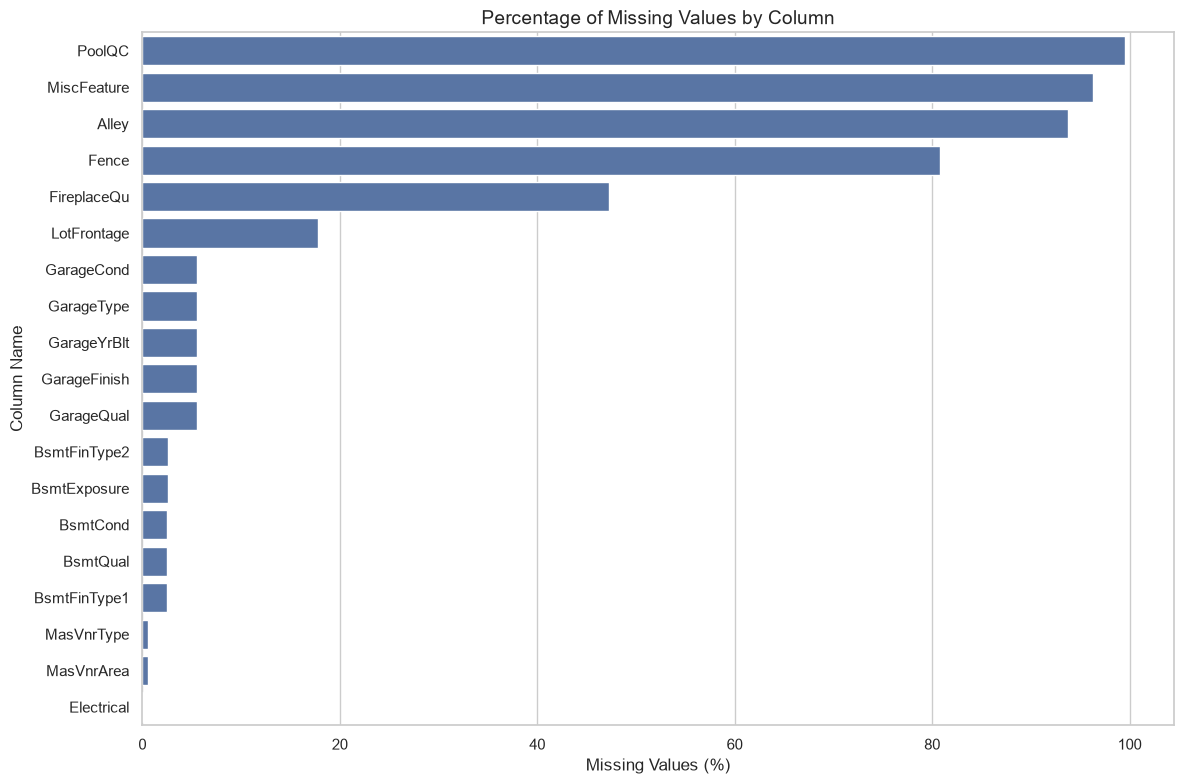

In [22]:
# Cell 27: Visualize Missing-Value Percentages

plt.figure(figsize=(12, 8))

sns.barplot(
    data=missing_summary.reset_index(),
    x="Missing_Percentage",
    y="index"
)

plt.title(
    "Percentage of Missing Values by Column",
    fontsize=14
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Column Name")

plt.tight_layout()
plt.show()

In [23]:
# Cell 28: Classify Missing Values by Meaning

missing_value_meaning = pd.DataFrame(
    {
        "Column_Group": [
            "PoolQC",
            "MiscFeature",
            "Alley",
            "Fence",
            "FireplaceQu",
            "Garage-related columns",
            "Basement-related columns",
            "LotFrontage",
            "MasVnrType and MasVnrArea",
            "Electrical",
        ],
        "Likely_Meaning": [
            "House probably has no pool",
            "House probably has no miscellaneous feature",
            "House probably has no alley access",
            "House probably has no fence",
            "House probably has no fireplace",
            "House probably has no garage",
            "House probably has no basement",
            "Street frontage measurement is unknown",
            "Masonry veneer information is unknown",
            "Electrical-system information is unknown",
        ],
        "Missing_Type": [
            "Structural absence",
            "Structural absence",
            "Structural absence",
            "Structural absence",
            "Structural absence",
            "Structural absence",
            "Structural absence",
            "Unknown numerical value",
            "Unknown feature information",
            "Unknown categorical value",
        ],
    }
)

missing_value_meaning

,Column_Group,Likely_Meaning,Missing_Type
0,PoolQC,House probably has no pool,Structural absence
1,MiscFeature,House probably has no miscellaneous feature,Structural absence
2,Alley,House probably has no alley access,Structural absence
3,Fence,House probably has no fence,Structural absence
4,FireplaceQu,House probably has no fireplace,Structural absence
5,Garage-related columns,House probably has no garage,Structural absence
6,Basement-related columns,House probably has no basement,Structural absence
7,LotFrontage,Street frontage measurement is unknown,Unknown numerical value
8,MasVnrType and MasVnrArea,Masonry veneer information is unknown,Unknown feature information
9,Electrical,Electrical-system information is unknown,Unknown categorical value


# Cell 29: Missing-Value Findings

The dataset contains 19 columns with at least one missing value.

Important observations:

- `PoolQC`, `MiscFeature`, `Alley`, and `Fence` have very high missing
  percentages.
- High missingness does not automatically mean that these columns are useless.
- For many categorical housing features, a missing marker represents the
  absence of the physical feature, such as no pool, no garage, or no basement.
- `LotFrontage` contains missing numerical measurements and will require an
  appropriate numerical imputation strategy.
- `MasVnrType`, `MasVnrArea`, and `Electrical` contain a small number of
  genuinely unknown values.
- No values have been filled, deleted, or modified during this EDA stage.
- Final missing-value handling will be performed during preprocessing without
  using information from the test set.

# Cell 30: Duplicate-Record Analysis

A duplicate record occurs when the same property observation appears more than
once in the dataset.

Repeated values in an individual column are normal. For example, many houses
can have the same number of bedrooms, neighborhood, or sale price.

A duplicate problem occurs when an entire property record is repeated.

Duplicate records can:

- Give repeated properties too much influence during model training
- Cause the same information to appear in both training and testing data
- Make model evaluation appear better than it actually is

Therefore, both exact duplicate rows and repeated property records should be
investigated.

In [24]:
# Cell 31: Check Exact Duplicate Rows

exact_duplicate_count = housing_df.duplicated().sum()

print("Number of exact duplicate rows:", exact_duplicate_count)

Number of exact duplicate rows: 0


In [25]:
# Cell 32: Check Identifier and Property Record Uniqueness

unique_id_count = housing_df["Id"].nunique()
duplicate_id_count = housing_df["Id"].duplicated().sum()

# Remove Id before checking whether property information is repeated
duplicate_properties_without_id = (
    housing_df
    .drop(columns=["Id"])
    .duplicated()
    .sum()
)

print("Total rows:", len(housing_df))
print("Number of unique Id values:", unique_id_count)
print("Number of duplicated Id values:", duplicate_id_count)
print(
    "Duplicate property records excluding Id:",
    duplicate_properties_without_id
)

Total rows: 1460
Number of unique Id values: 1460
Number of duplicated Id values: 0
Duplicate property records excluding Id: 0


# Cell 33: Duplicate Analysis Findings

The duplicate analysis shows that:

- The dataset contains no exact duplicate rows.
- Every `Id` value is unique.
- No duplicate property records were found after excluding the `Id` column.
- Therefore, no records need to be removed because of duplication at this
  stage.
- The `Id` column remains an identifier and will later be excluded from model
  training.

In [26]:
# Cell 34: Examine Important Numerical Value Ranges

important_numerical_columns = [
    "SalePrice",
    "LotArea",
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath",
    "HalfBath",
    "OverallQual",
    "OverallCond",
    "YearBuilt",
    "YearRemodAdd",
    "YrSold",
    "GarageCars",
    "PoolArea",
]

numerical_range_summary = (
    housing_df[important_numerical_columns]
    .agg(["count", "min", "max", "mean", "median"])
    .T
)

numerical_range_summary

,count,min,max,mean,median
SalePrice,1460.0,34900.0,755000.0,180921.195890,163000.0
LotArea,1460.0,1300.0,215245.0,10516.828082,9478.5
GrLivArea,1460.0,334.0,5642.0,1515.463699,1464.0
BedroomAbvGr,1460.0,0.0,8.0,2.866438,3.0
FullBath,1460.0,0.0,3.0,1.565068,2.0
HalfBath,1460.0,0.0,2.0,0.382877,0.0
OverallQual,1460.0,1.0,10.0,6.099315,6.0
OverallCond,1460.0,1.0,9.0,5.575342,5.0
YearBuilt,1460.0,1872.0,2010.0,1971.267808,1973.0
YearRemodAdd,1460.0,1950.0,2010.0,1984.865753,1994.0


In [27]:
# Cell 35: Perform Basic Validity Checks

validity_checks = {
    "SalePrice is zero or negative":
        (housing_df["SalePrice"] <= 0).sum(),

    "LotArea is zero or negative":
        (housing_df["LotArea"] <= 0).sum(),

    "GrLivArea is zero or negative":
        (housing_df["GrLivArea"] <= 0).sum(),

    "BedroomAbvGr is negative":
        (housing_df["BedroomAbvGr"] < 0).sum(),

    "OverallQual is outside 1 to 10":
        (
            (housing_df["OverallQual"] < 1)
            | (housing_df["OverallQual"] > 10)
        ).sum(),

    "OverallCond is outside 1 to 10":
        (
            (housing_df["OverallCond"] < 1)
            | (housing_df["OverallCond"] > 10)
        ).sum(),

    "YearBuilt is after YrSold":
        (housing_df["YearBuilt"] > housing_df["YrSold"]).sum(),

    "YearRemodAdd is before YearBuilt":
        (
            housing_df["YearRemodAdd"]
            < housing_df["YearBuilt"]
        ).sum(),

    "YearRemodAdd is after YrSold":
        (
            housing_df["YearRemodAdd"]
            > housing_df["YrSold"]
        ).sum(),
}

validity_results = pd.Series(
    validity_checks,
    name="Suspicious_Record_Count"
)

validity_results

SalePrice is zero or negative       0
LotArea is zero or negative         0
GrLivArea is zero or negative       0
BedroomAbvGr is negative            0
OverallQual is outside 1 to 10      0
OverallCond is outside 1 to 10      0
YearBuilt is after YrSold           0
YearRemodAdd is before YearBuilt    0
YearRemodAdd is after YrSold        1
Name: Suspicious_Record_Count, dtype: int64

In [28]:
# Cell 36: Display Records With Remodeling After Sale

suspicious_remodel_records = housing_df.loc[
    housing_df["YearRemodAdd"] > housing_df["YrSold"],
    [
        "Id",
        "YearBuilt",
        "YearRemodAdd",
        "YrSold",
        "SalePrice",
    ],
]

suspicious_remodel_records

,Id,YearBuilt,YearRemodAdd,YrSold,SalePrice
523,524,2007,2008,2007,184750


# Cell 37: Invalid and Suspicious Value Findings

The initial validity checks show that:

- No house has a zero or negative `SalePrice`.
- No property has a zero or negative `LotArea`.
- No property has a zero or negative above-ground living area.
- No negative bedroom counts were found.
- `OverallQual` and `OverallCond` remain within their expected ranges.
- No house was constructed after its recorded sale year.
- One property has a remodeling year later than its sale year and requires
  further investigation.
- Several variables contain extreme values, but extreme values are not
  automatically invalid.
- No rows or values have been removed or corrected at this stage.

# Cell 38: Univariate Analysis of the Target Variable

The target variable in this project is `SalePrice`.

Before training a regression model, the target variable must be examined to
understand:

- Its minimum and maximum values
- Its average and median
- Its spread
- Its distribution
- Its skewness
- Its possible outliers

Understanding the target helps determine whether transformations or special
treatment may be useful during modeling.

In [29]:
# Cell 39: Descriptive Statistics of SalePrice

saleprice_summary = housing_df["SalePrice"].describe()

saleprice_summary.to_frame(name="SalePrice Statistics")

,SalePrice Statistics
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


In [30]:
# Cell 40: Calculate Important SalePrice Statistics

saleprice_mean = housing_df["SalePrice"].mean()
saleprice_median = housing_df["SalePrice"].median()
saleprice_mode = housing_df["SalePrice"].mode().iloc[0]
saleprice_minimum = housing_df["SalePrice"].min()
saleprice_maximum = housing_df["SalePrice"].max()
saleprice_range = saleprice_maximum - saleprice_minimum
saleprice_standard_deviation = housing_df["SalePrice"].std()
saleprice_skewness = housing_df["SalePrice"].skew()

saleprice_statistics = pd.Series(
    {
        "Mean": saleprice_mean,
        "Median": saleprice_median,
        "Mode": saleprice_mode,
        "Minimum": saleprice_minimum,
        "Maximum": saleprice_maximum,
        "Range": saleprice_range,
        "Standard Deviation": saleprice_standard_deviation,
        "Skewness": saleprice_skewness,
    }
)

saleprice_statistics

Mean                  180921.195890
Median                163000.000000
Mode                  140000.000000
Minimum                34900.000000
Maximum               755000.000000
Range                 720100.000000
Standard Deviation     79442.502883
Skewness                   1.882876
dtype: float64

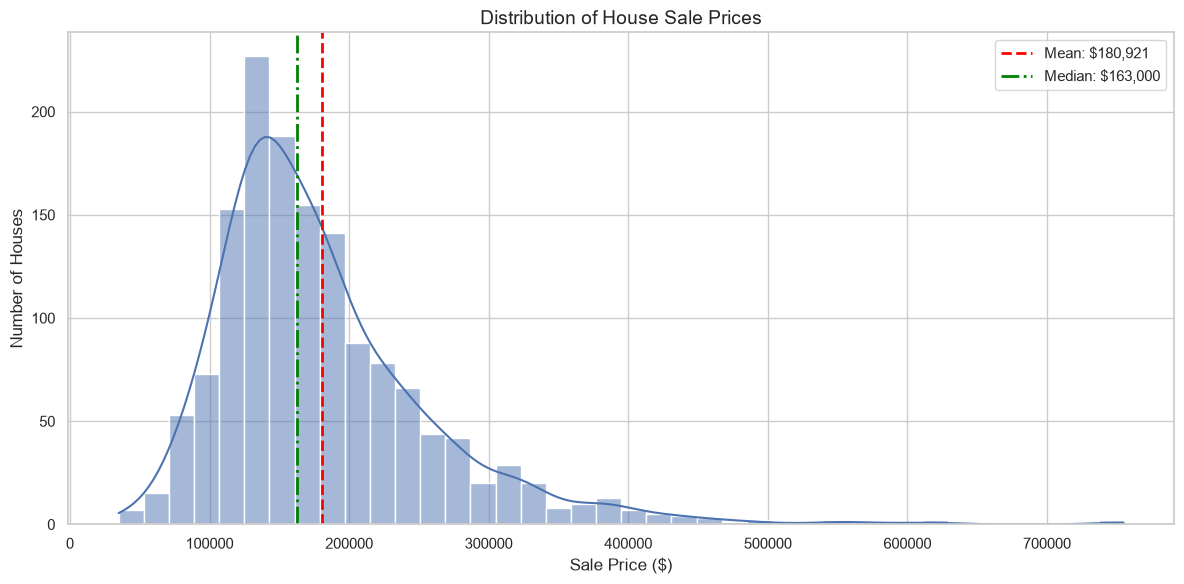

In [31]:
# Cell 41: Visualize the Distribution of SalePrice

plt.figure(figsize=(12, 6))

sns.histplot(
    data=housing_df,
    x="SalePrice",
    bins=40,
    kde=True
)

plt.axvline(
    saleprice_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: ${saleprice_mean:,.0f}"
)

plt.axvline(
    saleprice_median,
    color="green",
    linestyle="-.",
    linewidth=2,
    label=f"Median: ${saleprice_median:,.0f}"
)

plt.title("Distribution of House Sale Prices", fontsize=14)
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Houses")
plt.legend()

plt.tight_layout()
plt.show()

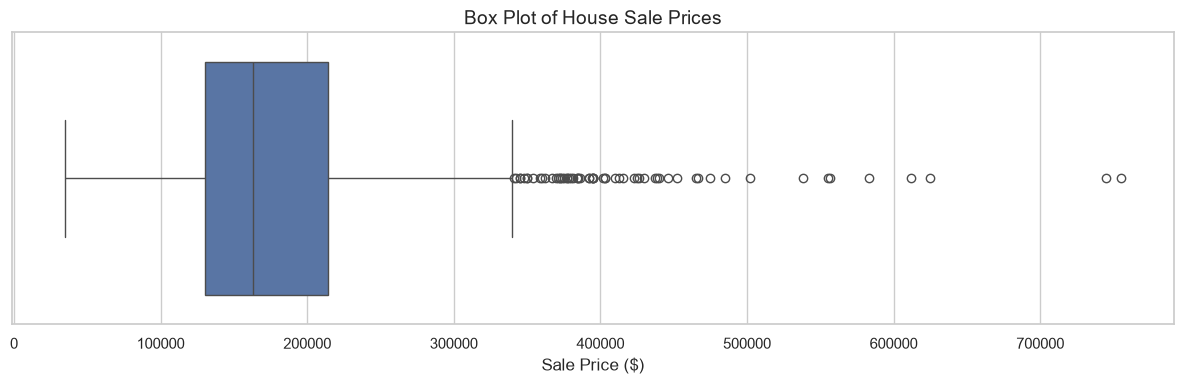

In [32]:
# Cell 42: Visualize Possible SalePrice Outliers

plt.figure(figsize=(12, 4))

sns.boxplot(
    data=housing_df,
    x="SalePrice"
)

plt.title("Box Plot of House Sale Prices", fontsize=14)
plt.xlabel("Sale Price ($)")

plt.tight_layout()
plt.show()

In [33]:
# Cell 43: Detect Possible SalePrice Outliers Using IQR

saleprice_q1 = housing_df["SalePrice"].quantile(0.25)
saleprice_q3 = housing_df["SalePrice"].quantile(0.75)

saleprice_iqr = saleprice_q3 - saleprice_q1

saleprice_lower_limit = saleprice_q1 - (1.5 * saleprice_iqr)
saleprice_upper_limit = saleprice_q3 + (1.5 * saleprice_iqr)

low_price_outliers = (
    housing_df["SalePrice"] < saleprice_lower_limit
).sum()

high_price_outliers = (
    housing_df["SalePrice"] > saleprice_upper_limit
).sum()

print("First quartile (Q1):", saleprice_q1)
print("Third quartile (Q3):", saleprice_q3)
print("Interquartile range:", saleprice_iqr)
print("Lower outlier limit:", saleprice_lower_limit)
print("Upper outlier limit:", saleprice_upper_limit)
print("Possible low-price outliers:", low_price_outliers)
print("Possible high-price outliers:", high_price_outliers)

First quartile (Q1): 129975.0
Third quartile (Q3): 214000.0
Interquartile range: 84025.0
Lower outlier limit: 3937.5
Upper outlier limit: 340037.5
Possible low-price outliers: 0
Possible high-price outliers: 61


In [34]:

# Cell 44: Inspect the Most Expensive Houses

expensive_house_columns = [
    "Id",
    "Neighborhood",
    "OverallQual",
    "YearBuilt",
    "GrLivArea",
    "GarageCars",
    "SalePrice",
]

housing_df[
    expensive_house_columns
].sort_values(
    by="SalePrice",
    ascending=False
).head(10)

,Id,Neighborhood,OverallQual,YearBuilt,GrLivArea,GarageCars,SalePrice
691,692,NoRidge,10,1994,4316,3,755000
1182,1183,NoRidge,10,1996,4476,3,745000
1169,1170,NoRidge,10,1995,3627,3,625000
898,899,NridgHt,9,2009,2364,3,611657
803,804,NridgHt,9,2008,2822,3,582933
1046,1047,StoneBr,9,2005,2868,3,556581
440,441,NridgHt,10,2008,2402,3,555000
769,770,StoneBr,8,2003,3279,3,538000
178,179,StoneBr,9,2008,2234,3,501837
798,799,NridgHt,9,2008,3140,3,485000


In [35]:
# Cell 45: Create a Temporary Log-Transformed SalePrice

saleprice_log = np.log1p(housing_df["SalePrice"])

print(
    "Original SalePrice skewness:",
    round(housing_df["SalePrice"].skew(), 3)
)

print(
    "Log-transformed SalePrice skewness:",
    round(saleprice_log.skew(), 3)
)

Original SalePrice skewness: 1.883
Log-transformed SalePrice skewness: 0.121


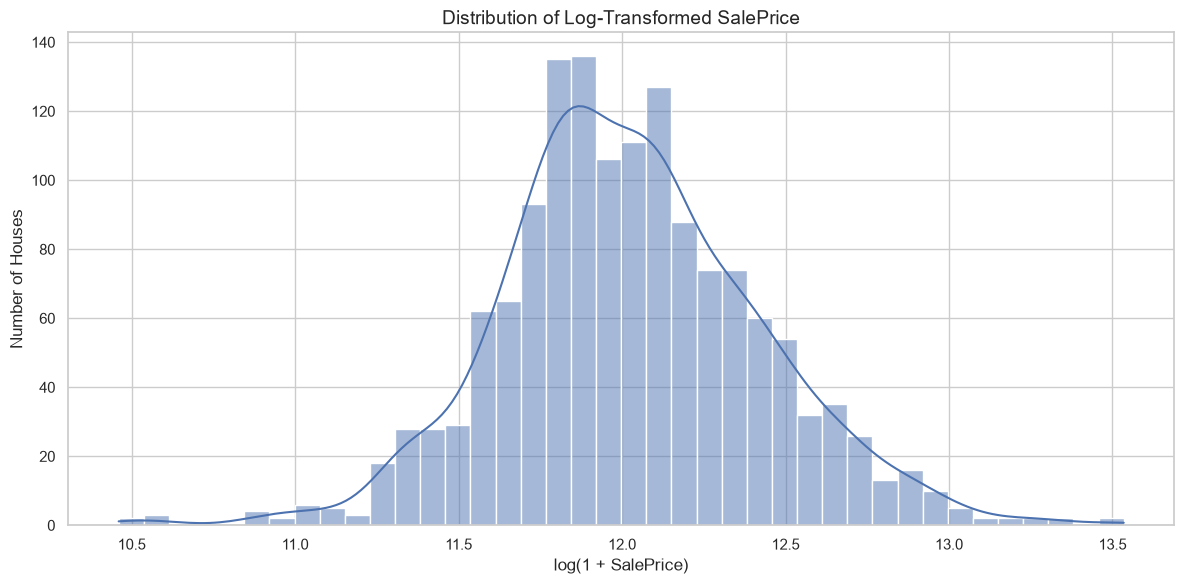

In [36]:
# Cell 46: Visualize Log-Transformed SalePrice

plt.figure(figsize=(12, 6))

sns.histplot(
    saleprice_log,
    bins=40,
    kde=True
)

plt.title(
    "Distribution of Log-Transformed SalePrice",
    fontsize=14
)

plt.xlabel("log(1 + SalePrice)")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.show()

# Cell 47: SalePrice Analysis Findings

The target-variable analysis produced the following findings:

- The dataset contains 1,460 available sale-price values.
- The mean sale price is approximately $180,921.
- The median sale price is approximately $163,000.
- The mean is greater than the median, indicating that expensive houses pull
  the average upward.
- The original `SalePrice` distribution is strongly right-skewed.
- The original skewness is approximately 1.88.
- The box plot and IQR method identify 61 possible high-price outliers.
- These observations must not be removed automatically because they may
  represent valid expensive properties.
- A temporary logarithmic transformation reduces the target skewness to
  approximately 0.12.
- The original target column has not been modified.
- The usefulness of target transformation will be evaluated during model
  development.

# Cell 48: Univariate Analysis of Numerical Features

Numerical univariate analysis examines one numerical feature at a time.

The purpose is to understand:

- The central value of each feature
- The spread of its values
- Its minimum and maximum
- Its distribution
- Its skewness
- The number of zero values
- Its possible outliers
- Whether the recorded values appear realistic

This analysis helps identify which numerical features may require imputation,
transformation, scaling, or further investigation during preprocessing.

No values will be removed or modified during this stage.

In [37]:
# Cell 49: Create Numerical Feature Summary

numerical_summary = pd.DataFrame(
    index=numerical_feature_columns
)

numerical_summary["Non_Missing_Count"] = (
    housing_df[numerical_feature_columns].count()
)

numerical_summary["Missing_Count"] = (
    housing_df[numerical_feature_columns].isna().sum()
)

numerical_summary["Missing_Percentage"] = (
    housing_df[numerical_feature_columns].isna().mean() * 100
)

numerical_summary["Unique_Values"] = (
    housing_df[numerical_feature_columns].nunique()
)

numerical_summary["Mean"] = (
    housing_df[numerical_feature_columns].mean()
)

numerical_summary["Median"] = (
    housing_df[numerical_feature_columns].median()
)

numerical_summary["Standard_Deviation"] = (
    housing_df[numerical_feature_columns].std()
)

numerical_summary["Minimum"] = (
    housing_df[numerical_feature_columns].min()
)

numerical_summary["Maximum"] = (
    housing_df[numerical_feature_columns].max()
)

numerical_summary["Skewness"] = (
    housing_df[numerical_feature_columns].skew()
)

numerical_summary["Zero_Count"] = (
    housing_df[numerical_feature_columns].eq(0).sum()
)

numerical_summary["Zero_Percentage"] = (
    housing_df[numerical_feature_columns].eq(0).mean() * 100
)

numerical_summary = numerical_summary.round(2)

numerical_summary

,Non_Missing_Count,Missing_Count,Missing_Percentage,Unique_Values,Mean,Median,Standard_Deviation,Minimum,Maximum,Skewness,Zero_Count,Zero_Percentage
LotFrontage,1201,259,17.74,110,70.05,69.0,24.28,21.0,313.0,2.16,0,0.00
LotArea,1460,0,0.00,1073,10516.83,9478.5,9981.26,1300.0,215245.0,12.21,0,0.00
OverallQual,1460,0,0.00,10,6.10,6.0,1.38,1.0,10.0,0.22,0,0.00
OverallCond,1460,0,0.00,9,5.58,5.0,1.11,1.0,9.0,0.69,0,0.00
YearBuilt,1460,0,0.00,112,1971.27,1973.0,30.20,1872.0,2010.0,-0.61,0,0.00
YearRemodAdd,1460,0,0.00,61,1984.87,1994.0,20.65,1950.0,2010.0,-0.50,0,0.00
MasVnrArea,1452,8,0.55,327,103.69,0.0,181.07,0.0,1600.0,2.67,861,58.97
BsmtFinSF1,1460,0,0.00,637,443.64,383.5,456.10,0.0,5644.0,1.69,467,31.99
BsmtFinSF2,1460,0,0.00,144,46.55,0.0,161.32,0.0,1474.0,4.26,1293,88.56
BsmtUnfSF,1460,0,0.00,780,567.24,477.5,441.87,0.0,2336.0,0.92,118,8.08


In [38]:
# Cell 50: Identify Highly Skewed Numerical Features

skewness_summary = numerical_summary[
    ["Skewness"]
].copy()

skewness_summary["Absolute_Skewness"] = (
    skewness_summary["Skewness"].abs()
)

skewness_summary = skewness_summary.sort_values(
    by="Absolute_Skewness",
    ascending=False
)

skewness_summary.head(15)

,Skewness,Absolute_Skewness
MiscVal,24.48,24.48
PoolArea,14.83,14.83
LotArea,12.21,12.21
3SsnPorch,10.30,10.30
LowQualFinSF,9.01,9.01
KitchenAbvGr,4.49,4.49
BsmtFinSF2,4.26,4.26
ScreenPorch,4.12,4.12
BsmtHalfBath,4.10,4.10
EnclosedPorch,3.09,3.09


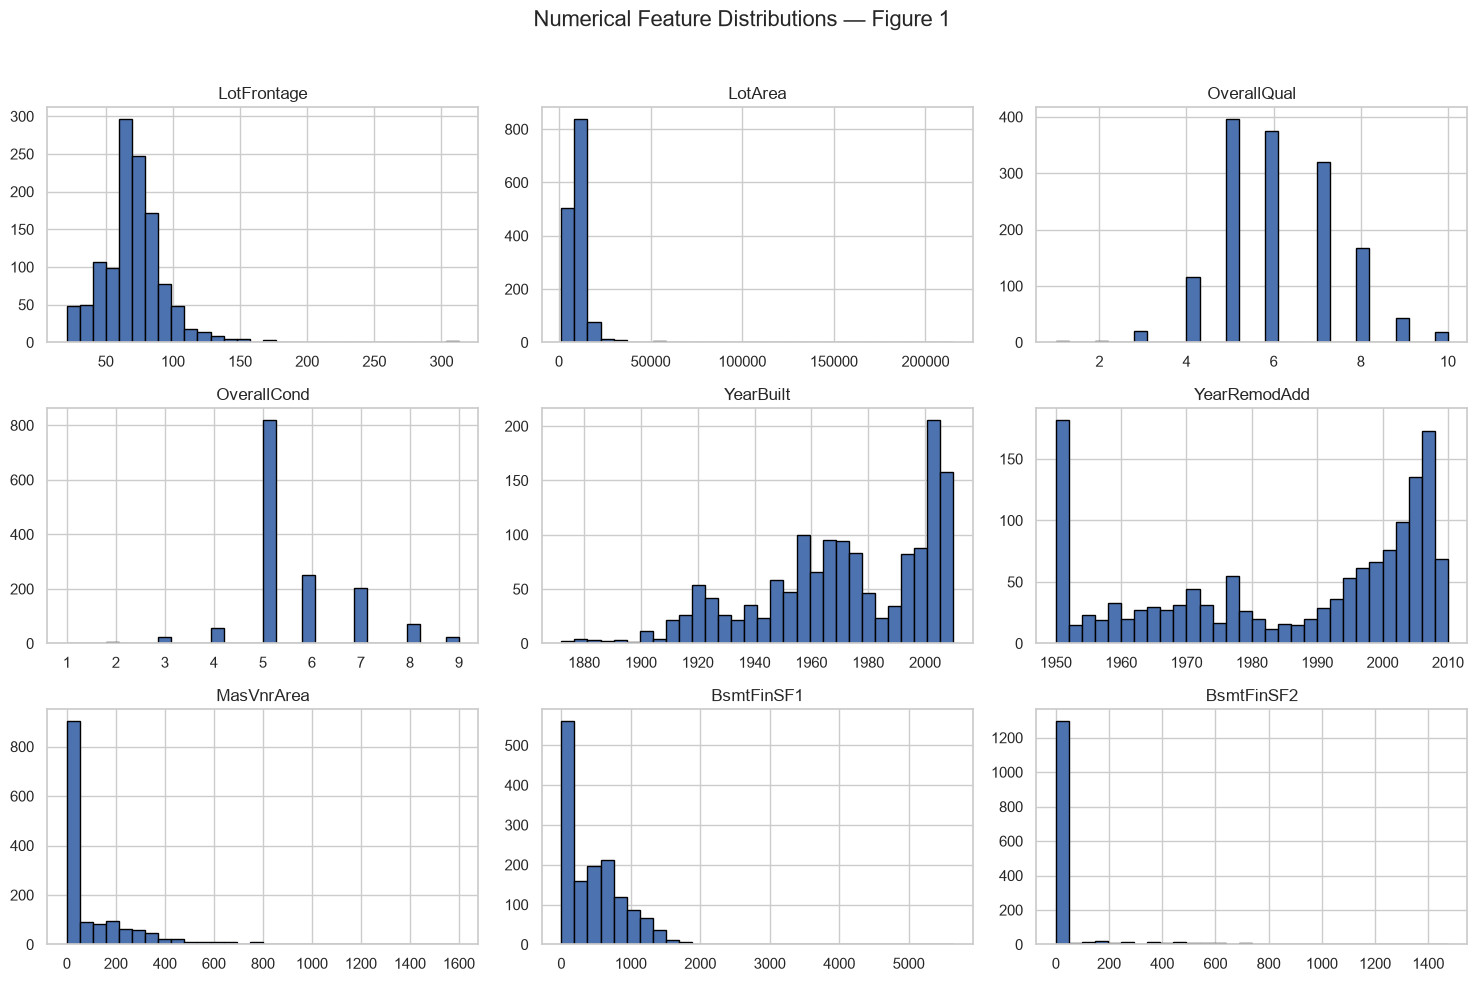

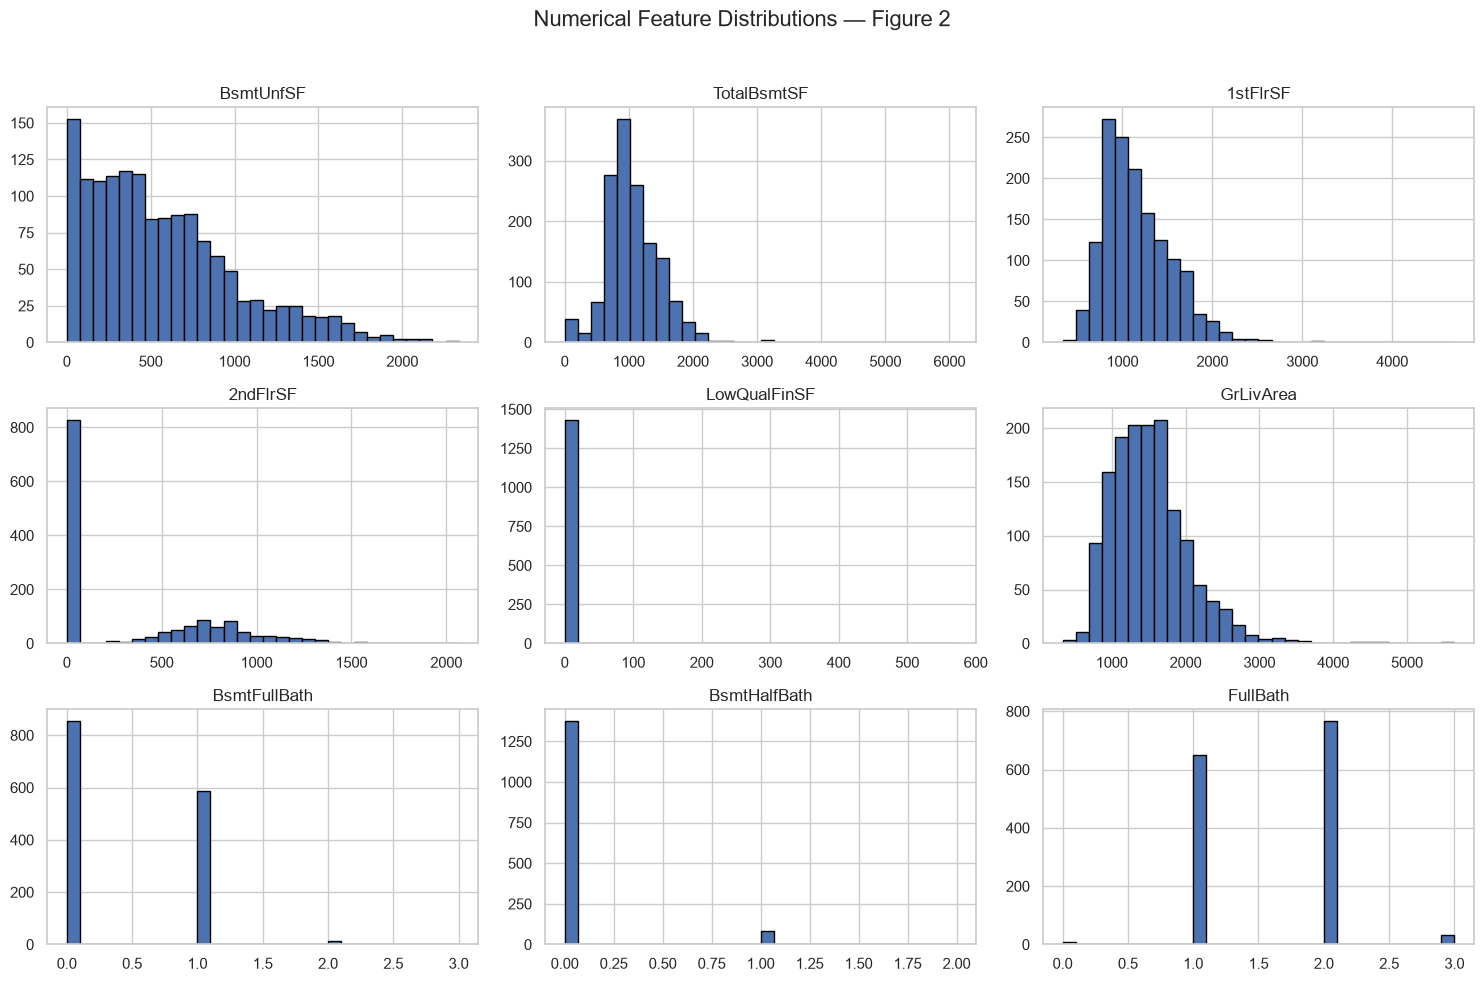

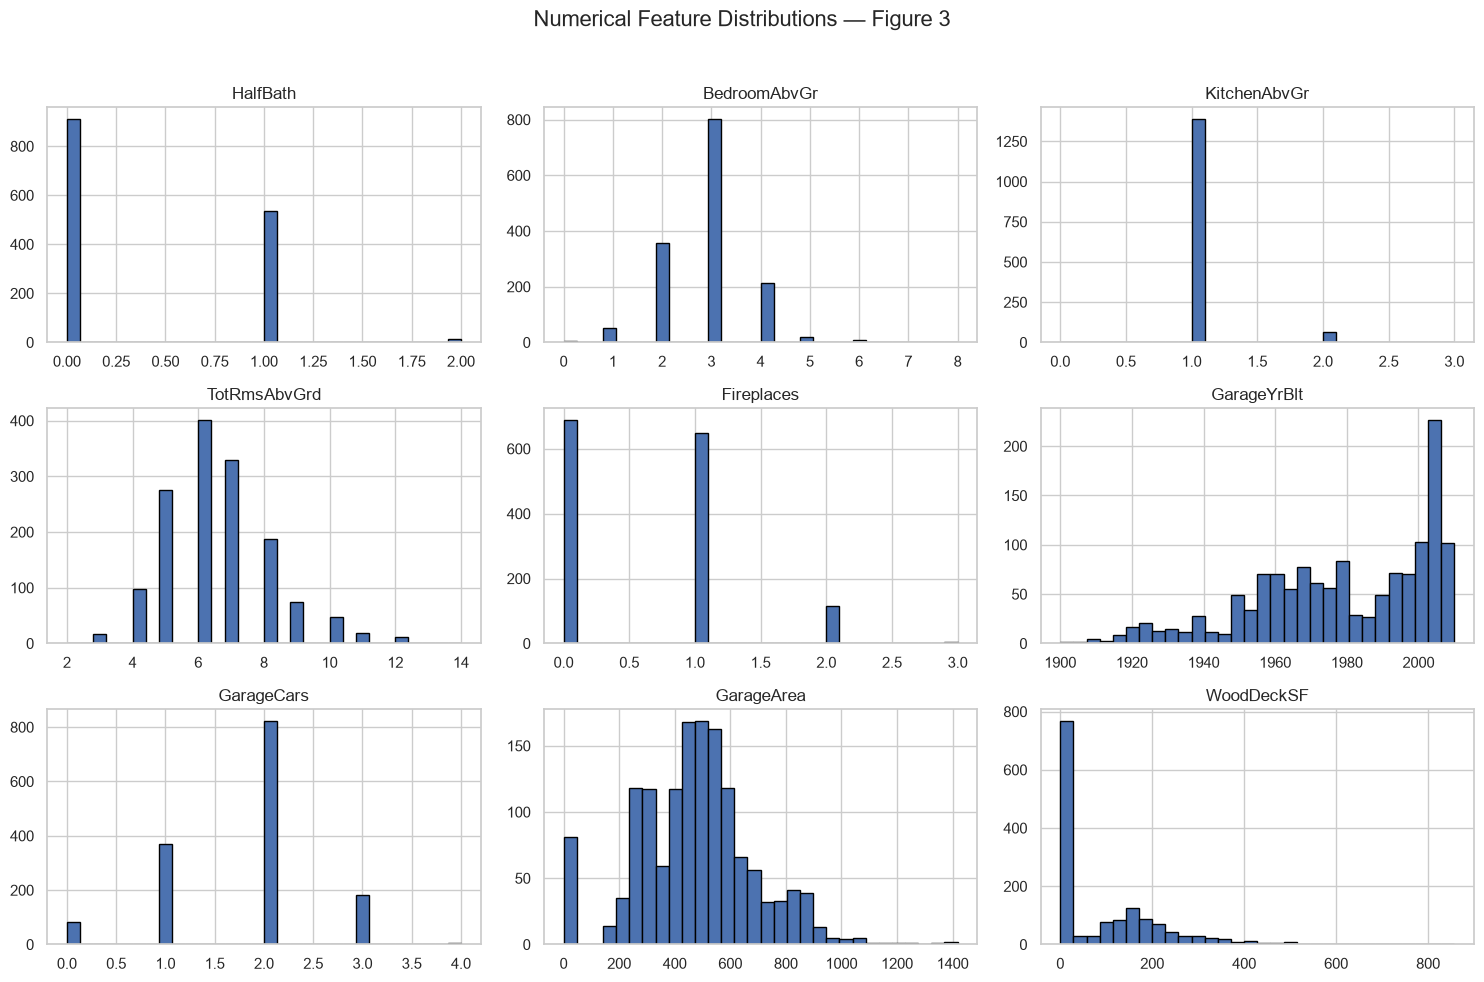

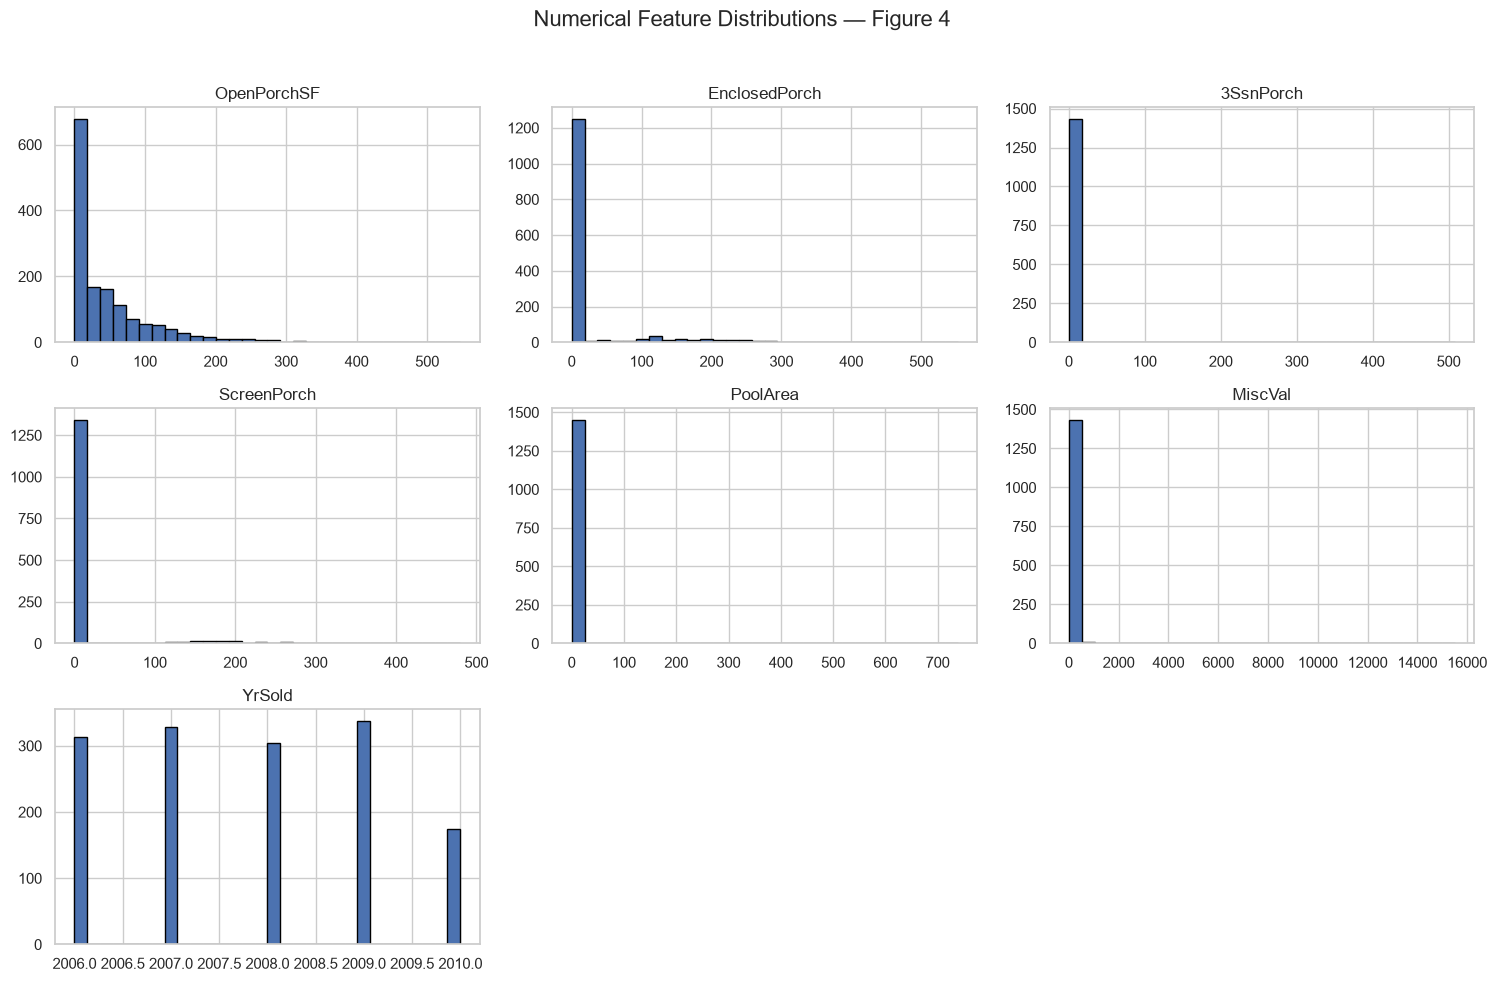

In [39]:
# Cell 51: Visualize All Numerical Feature Distributions

features_per_figure = 9

for start_index in range(
    0,
    len(numerical_feature_columns),
    features_per_figure
):
    feature_batch = numerical_feature_columns[
        start_index:start_index + features_per_figure
    ]

    housing_df[feature_batch].hist(
        bins=30,
        figsize=(15, 10),
        layout=(3, 3),
        edgecolor="black"
    )

    figure_number = (
        start_index // features_per_figure
    ) + 1

    plt.suptitle(
        f"Numerical Feature Distributions — Figure {figure_number}",
        fontsize=16
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.96]
    )

    plt.show()

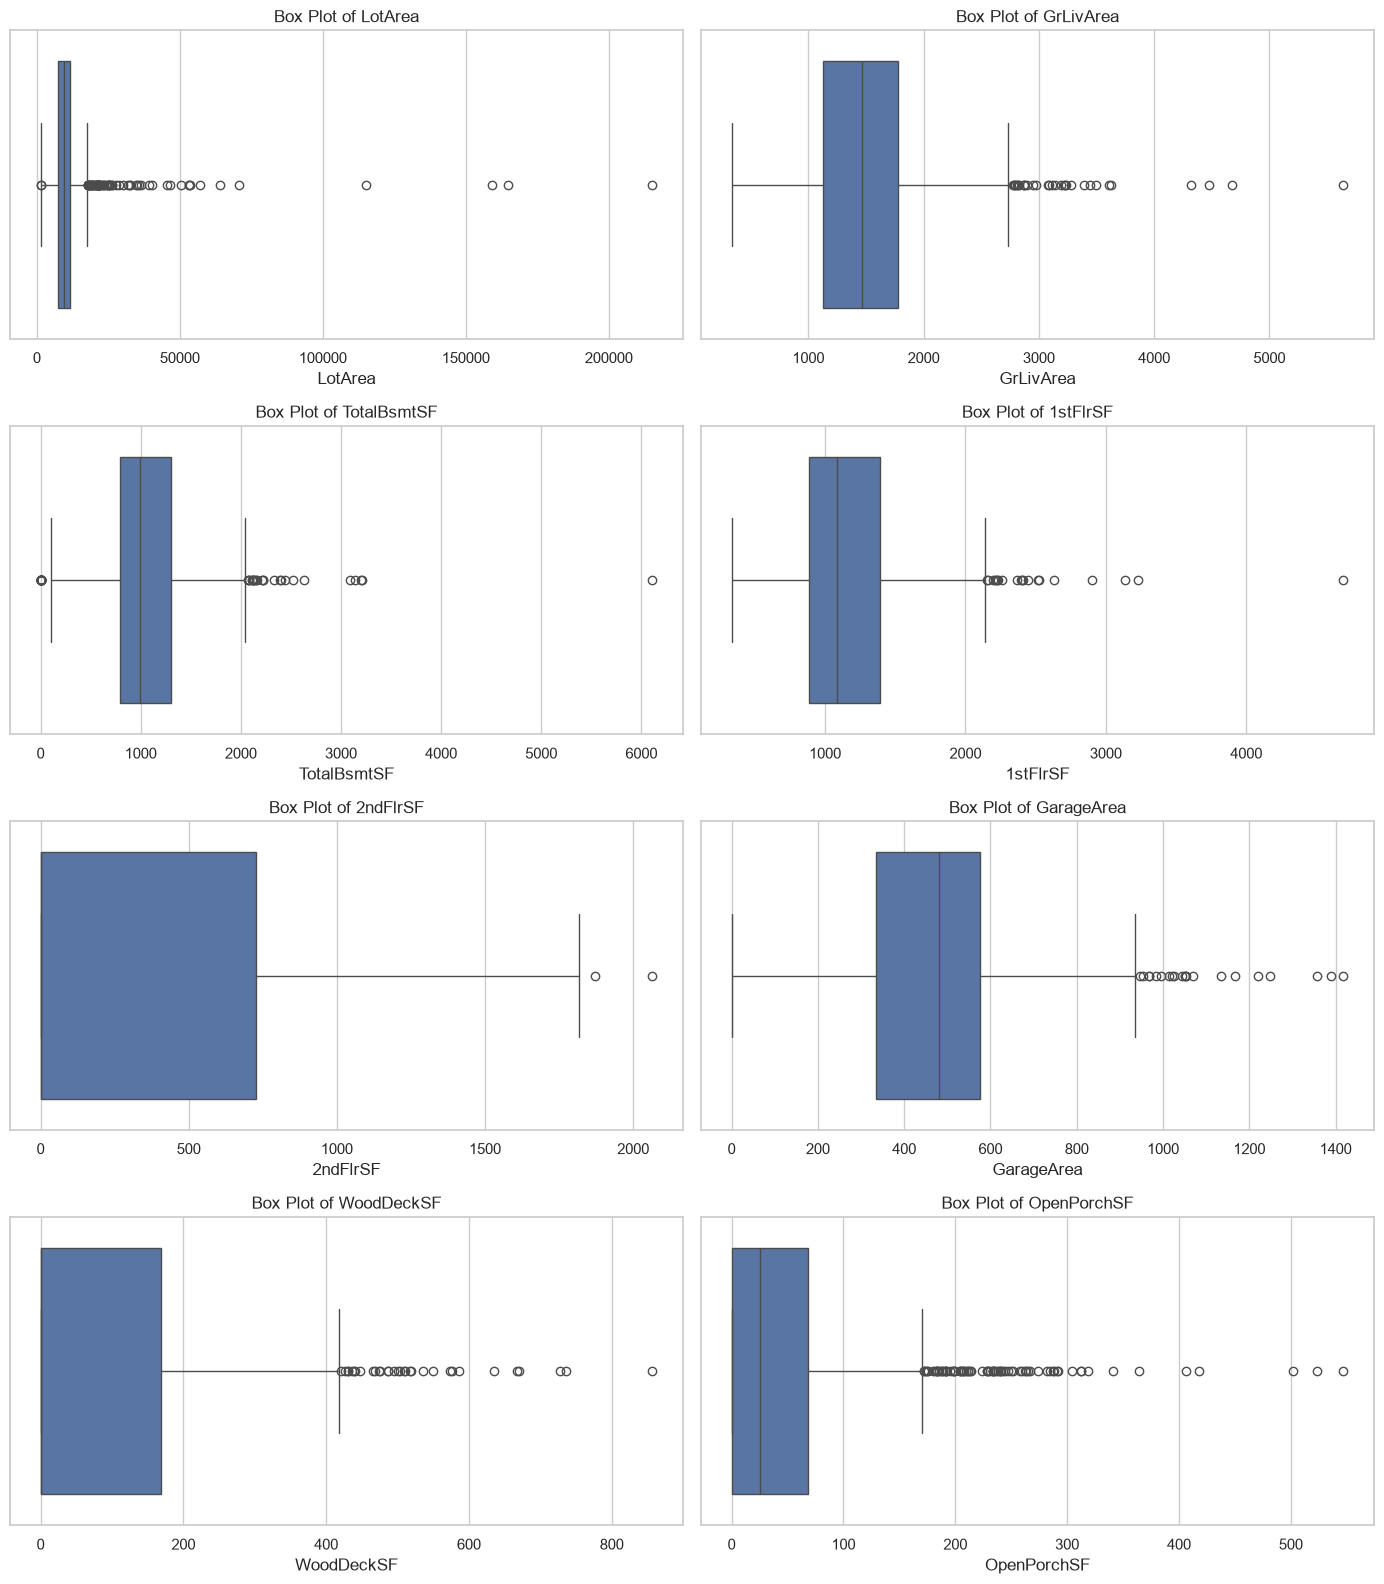

In [40]:
# Cell 52: Box Plots of Important Continuous Features

key_continuous_features = [
    "LotArea",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
]

figure, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 16)
)

axes = axes.flatten()

for axis, column in zip(
    axes,
    key_continuous_features
):
    sns.boxplot(
        data=housing_df,
        x=column,
        ax=axis
    )

    axis.set_title(
        f"Box Plot of {column}"
    )

    axis.set_xlabel(column)

plt.tight_layout()
plt.show()

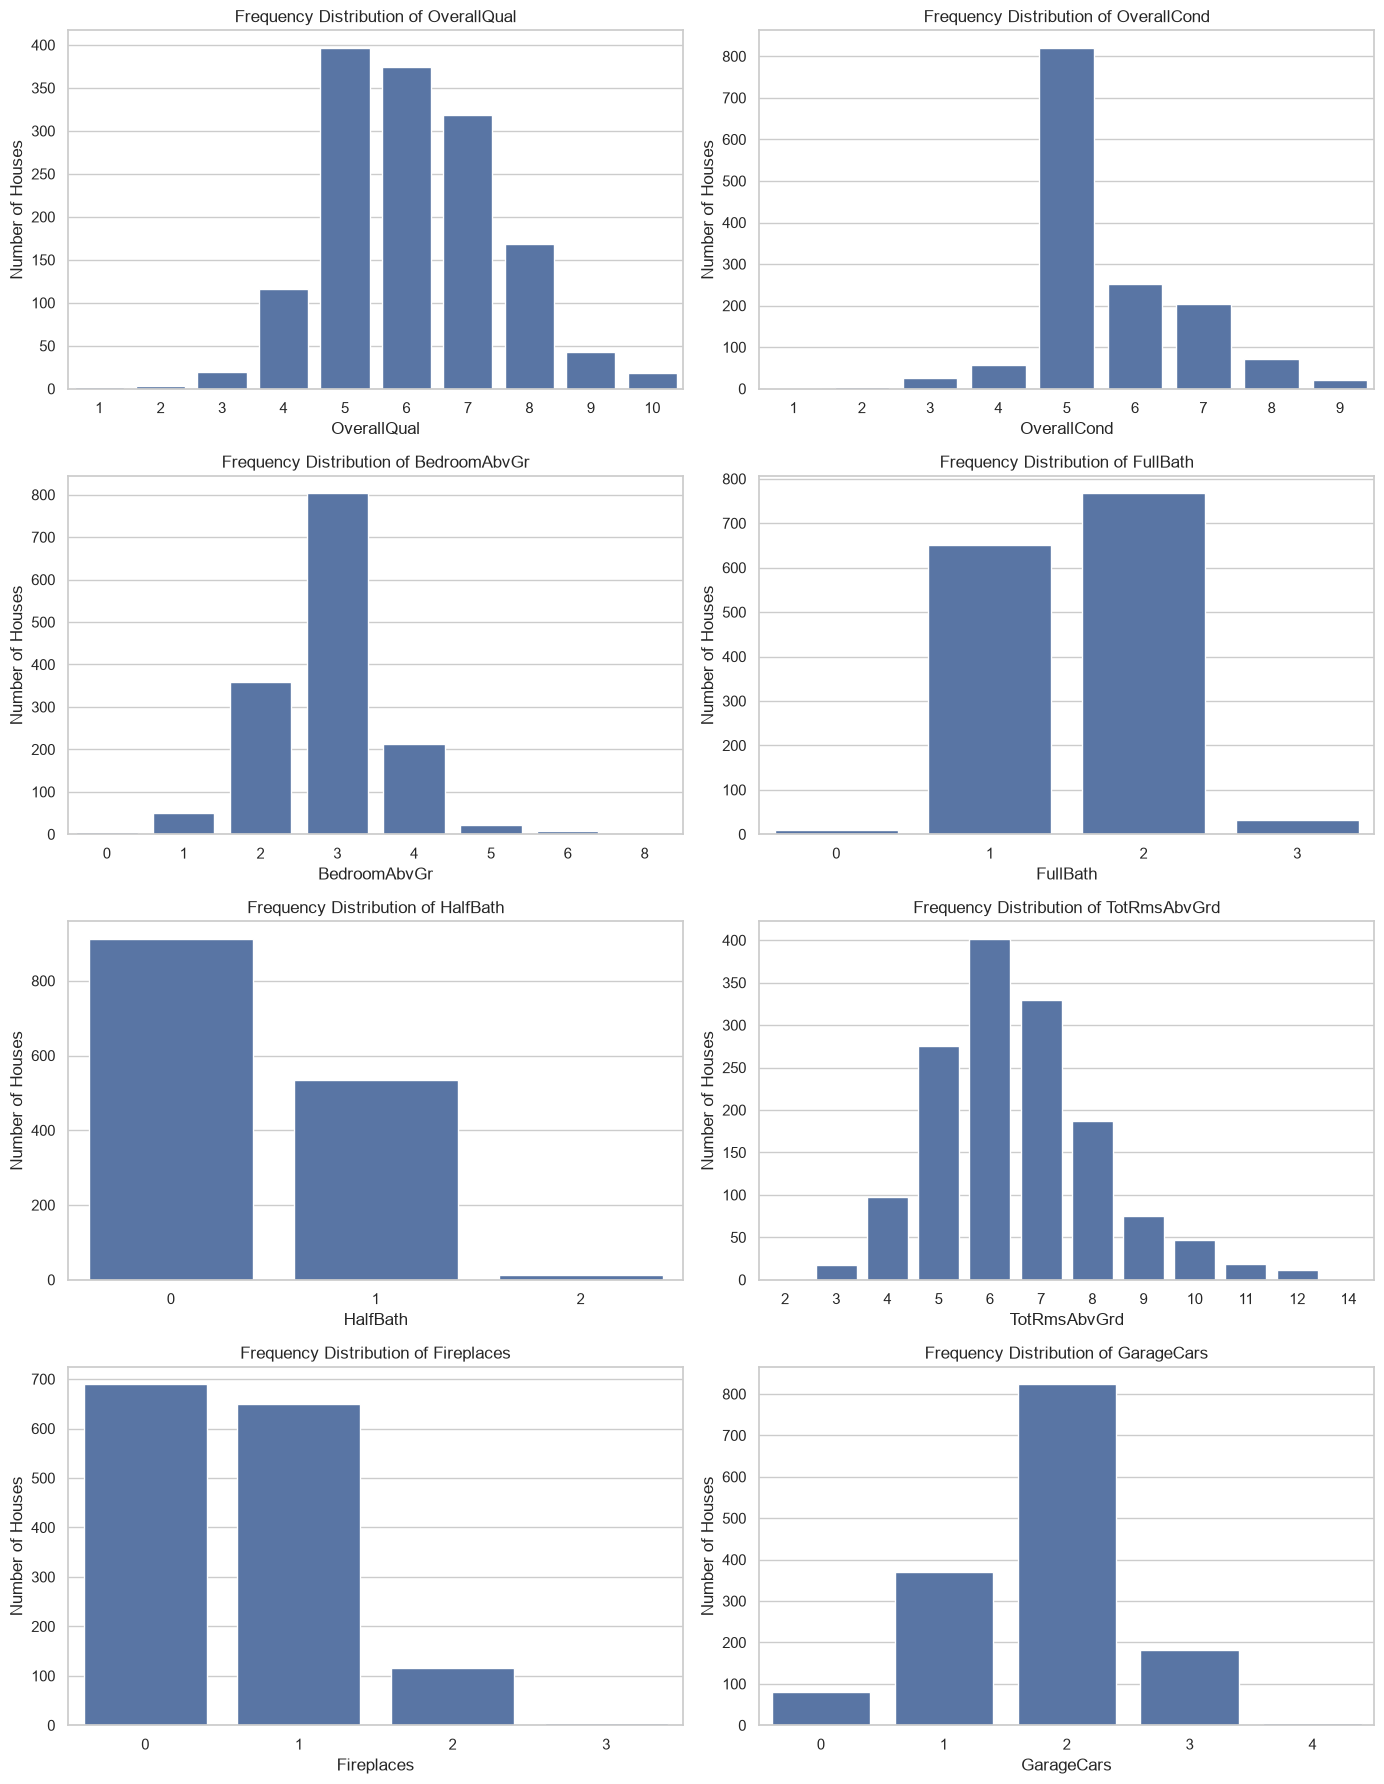

In [41]:
# Cell 53: Visualize Important Discrete and Ordinal Features

key_discrete_features = [
    "OverallQual",
    "OverallCond",
    "BedroomAbvGr",
    "FullBath",
    "HalfBath",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageCars",
]

figure, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 18)
)

axes = axes.flatten()

for axis, column in zip(
    axes,
    key_discrete_features
):
    category_order = sorted(
        housing_df[column]
        .dropna()
        .unique()
    )

    sns.countplot(
        data=housing_df,
        x=column,
        order=category_order,
        ax=axis
    )

    axis.set_title(
        f"Frequency Distribution of {column}"
    )

    axis.set_xlabel(column)
    axis.set_ylabel("Number of Houses")

plt.tight_layout()
plt.show()

In [42]:
# Cell 54: Identify Zero-Heavy Numerical Features

zero_value_summary = pd.DataFrame(
    {
        "Zero_Count": (
            housing_df[numerical_feature_columns]
            .eq(0)
            .sum()
        ),
        "Zero_Percentage": (
            housing_df[numerical_feature_columns]
            .eq(0)
            .mean()
            * 100
        ),
    }
)

zero_value_summary = zero_value_summary[
    zero_value_summary["Zero_Count"] > 0
]

zero_value_summary = zero_value_summary.sort_values(
    by="Zero_Percentage",
    ascending=False
)

zero_value_summary["Zero_Percentage"] = (
    zero_value_summary["Zero_Percentage"]
    .round(2)
)

zero_value_summary

,Zero_Count,Zero_Percentage
PoolArea,1453,99.52
3SsnPorch,1436,98.36
LowQualFinSF,1434,98.22
MiscVal,1408,96.44
BsmtHalfBath,1378,94.38
ScreenPorch,1344,92.05
BsmtFinSF2,1293,88.56
EnclosedPorch,1252,85.75
HalfBath,913,62.53
MasVnrArea,861,58.97


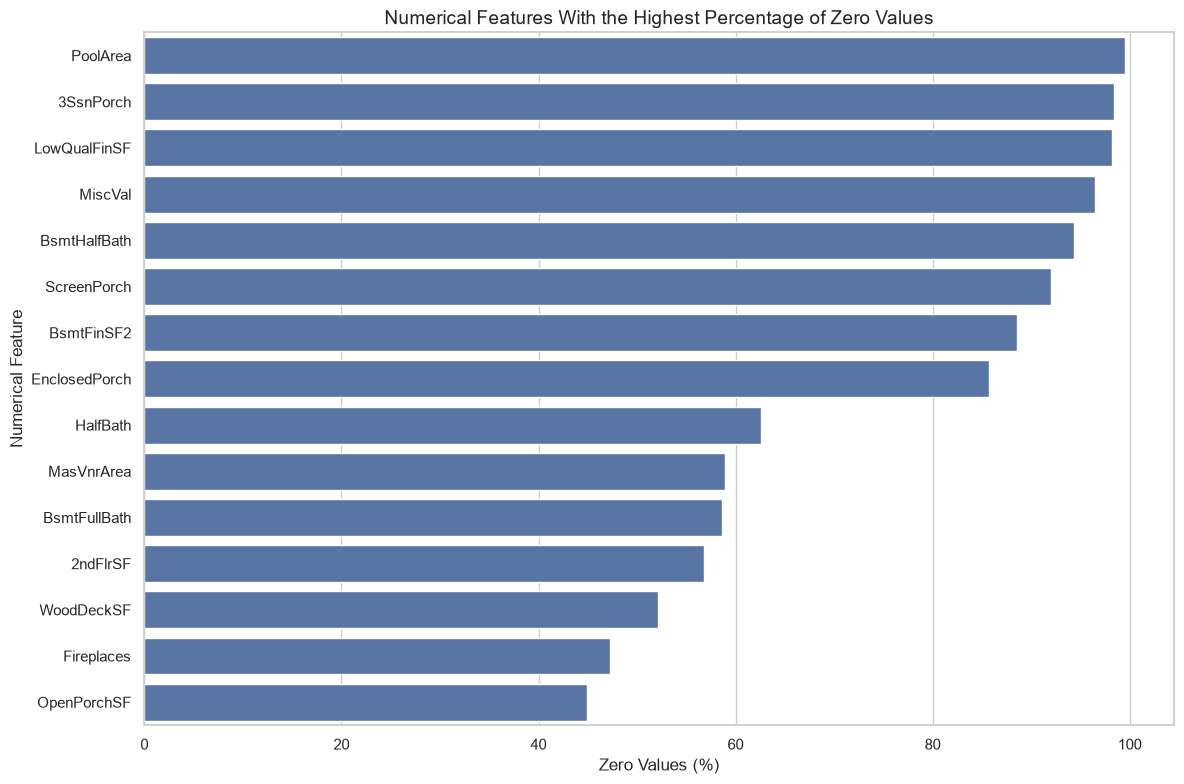

In [43]:
# Cell 55: Visualize Zero-Heavy Numerical Features

top_zero_features = (
    zero_value_summary
    .head(15)
    .reset_index()
    .rename(columns={"index": "Feature"})
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_zero_features,
    x="Zero_Percentage",
    y="Feature"
)

plt.title(
    "Numerical Features With the Highest Percentage of Zero Values",
    fontsize=14
)

plt.xlabel("Zero Values (%)")
plt.ylabel("Numerical Feature")

plt.tight_layout()
plt.show()

In [44]:
# Cell 56: Screen Continuous Features for Possible Outliers

continuous_outlier_columns = [
    "LotFrontage",
    "LotArea",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "GarageArea",
]

outlier_results = []

for column in continuous_outlier_columns:
    feature_values = housing_df[column].dropna()

    first_quartile = feature_values.quantile(0.25)
    third_quartile = feature_values.quantile(0.75)

    interquartile_range = (
        third_quartile - first_quartile
    )

    lower_limit = (
        first_quartile
        - 1.5 * interquartile_range
    )

    upper_limit = (
        third_quartile
        + 1.5 * interquartile_range
    )

    outlier_count = (
        (
            feature_values < lower_limit
        )
        |
        (
            feature_values > upper_limit
        )
    ).sum()

    outlier_percentage = (
        outlier_count
        / len(feature_values)
    ) * 100

    outlier_results.append(
        {
            "Feature": column,
            "Q1": first_quartile,
            "Q3": third_quartile,
            "IQR": interquartile_range,
            "Lower_Limit": lower_limit,
            "Upper_Limit": upper_limit,
            "Possible_Outliers": outlier_count,
            "Outlier_Percentage": outlier_percentage,
        }
    )

continuous_outlier_summary = pd.DataFrame(
    outlier_results
)

continuous_outlier_summary = (
    continuous_outlier_summary
    .round(2)
)

continuous_outlier_summary

,Feature,Q1,Q3,IQR,Lower_Limit,Upper_Limit,Possible_Outliers,Outlier_Percentage
0,LotFrontage,59.00,80.00,21.00,27.50,111.50,88,7.33
1,LotArea,7553.50,11601.50,4048.00,1481.50,17673.50,69,4.73
2,GrLivArea,1129.50,1776.75,647.25,158.62,2747.62,31,2.12
3,TotalBsmtSF,795.75,1298.25,502.50,42.00,2052.00,61,4.18
4,1stFlrSF,882.00,1391.25,509.25,118.12,2155.12,20,1.37
5,GarageArea,334.50,576.00,241.50,-27.75,938.25,21,1.44


In [45]:
# Cell 57: Inspect Houses With the Largest Living Areas

large_living_area_columns = [
    "Id",
    "Neighborhood",
    "OverallQual",
    "YearBuilt",
    "GrLivArea",
    "TotalBsmtSF",
    "GarageCars",
    "SalePrice",
]

largest_houses = (
    housing_df[large_living_area_columns]
    .sort_values(
        by="GrLivArea",
        ascending=False
    )
    .head(10)
)

largest_houses

,Id,Neighborhood,OverallQual,YearBuilt,GrLivArea,TotalBsmtSF,GarageCars,SalePrice
1298,1299,Edwards,10,2008,5642,6110,2,160000
523,524,Edwards,10,2007,4676,3138,3,184750
1182,1183,NoRidge,10,1996,4476,2396,3,745000
691,692,NoRidge,10,1994,4316,2444,3,755000
1169,1170,NoRidge,10,1995,3627,1930,3,625000
185,186,OldTown,10,1892,3608,1107,3,475000
304,305,OldTown,7,1880,3493,1470,3,295000
1268,1269,Crawfor,8,1935,3447,728,3,381000
635,636,SWISU,6,1914,3395,1440,0,200000
769,770,StoneBr,8,2003,3279,1650,3,538000


# Cell 58: Numerical Feature Analysis Findings

The univariate numerical analysis produced the following observations:

- The dataset contains numerical measurements, count variables, ordered scores,
  and year-related features.
- Several area-related features are positively skewed because most properties
  have moderate values while a small number of properties are extremely large.
- Some numerical features contain a high percentage of zero values.
- In many cases, zero represents the absence of a property feature rather than
  missing or incorrect information.
- `PoolArea`, porch-area variables, miscellaneous value, and low-quality
  finished area are examples of zero-heavy features.
- Count plots show that some bedroom, bathroom, room, quality, and garage
  values are much more common than others.
- Box plots and the IQR method identify several possible outliers in continuous
  features.
- Statistically unusual values have not been removed because they may represent
  valid large or luxury properties.
- Further investigation will be performed during bivariate and multivariate
  analysis.
- No numerical feature has been transformed, scaled, filled, or deleted at
  this stage.

# Cell 59: EDA Conclusion and Preprocessing Plan

The exploratory data analysis identified numerical and categorical features,
missing values, zero-heavy features, possible outliers, and a right-skewed
target variable.

The following preprocessing decisions will be used:

- `Id` will be removed because it is only a record identifier.
- `SalePrice` will be separated as the target variable.
- The dataset will be divided into training and testing sets before fitting
  preprocessing operations.
- Missing `LotFrontage` values will be filled using the training-set median.
- Missing `GarageYrBlt` and `MasVnrArea` values will be filled with zero.
- Missing categorical values will be represented by a separate `Missing`
  category.
- Categorical features will be converted into numerical columns using
  one-hot encoding.
- Unknown categories appearing in test data will be handled safely.
- A Linear Regression model will be trained using the processed training data.

In [46]:
# Cell 60: Separate Input Features and Target

X = housing_df.drop(
    columns=["Id", "SalePrice"]
)

y = housing_df["SalePrice"]

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

Input feature shape: (1460, 79)
Target shape: (1460,)


In [47]:
# Cell 61: Split the Dataset Into Training and Testing Sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training input shape:", X_train.shape)
print("Testing input shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training input shape: (1168, 79)
Testing input shape: (292, 79)
Training target shape: (1168,)
Testing target shape: (292,)


In [48]:
# Cell 62: Identify Numerical and Categorical Training Features

numeric_code_categories = [
    "MSSubClass",
    "MoSold",
]

categorical_columns = (
    X_train.select_dtypes(include=["object"])
    .columns
    .tolist()
    + numeric_code_categories
)

numerical_columns = [
    column
    for column in X_train.select_dtypes(
        include=["int64", "float64"]
    ).columns
    if column not in categorical_columns
]

print("Numerical features:", len(numerical_columns))
print("Categorical features:", len(categorical_columns))
print(
    "Total features classified:",
    len(numerical_columns) + len(categorical_columns)
)

Numerical features: 34
Categorical features: 45
Total features classified: 79


C:\Users\Hp\AppData\Local\Temp\ipykernel_2992\3717630610.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.select_dtypes(include=["object"])


In [49]:
# Cell 63: Define Numerical Missing-Value Strategies

zero_imputation_columns = [
    column
    for column in [
        "GarageYrBlt",
        "MasVnrArea",
    ]
    if column in numerical_columns
]

median_imputation_columns = [
    column
    for column in numerical_columns
    if column not in zero_imputation_columns
]

print(
    "Numerical columns filled with zero:",
    zero_imputation_columns
)

print(
    "Number of numerical columns filled with median:",
    len(median_imputation_columns)
)

Numerical columns filled with zero: ['GarageYrBlt', 'MasVnrArea']
Number of numerical columns filled with median: 32


In [50]:
# Cell 64: Create the Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

median_numerical_pipeline = Pipeline(
    steps=[
        (
            "median_imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

zero_numerical_pipeline = Pipeline(
    steps=[
        (
            "zero_imputer",
            SimpleImputer(
                strategy="constant",
                fill_value=0
            )
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "categorical_imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "one_hot_encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "median_numerical",
            median_numerical_pipeline,
            median_imputation_columns
        ),
        (
            "zero_numerical",
            zero_numerical_pipeline,
            zero_imputation_columns
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_columns
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [51]:
# Cell 65: Create the Complete Linear Regression Pipeline

from sklearn.linear_model import LinearRegression

linear_regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "linear_regression",
            LinearRegression()
        )
    ]
)

print("Complete model pipeline created successfully.")

Complete model pipeline created successfully.


In [52]:
#Cell 66: Train the LIner Regression Model

linear_regression_pipeline.fit(
    X_train,
    y_train
)

print("Linear Regression model trained successfully")


Linear Regression model trained successfully


In [53]:
# Cell 67: Generate House Price Predictions

y_pred = linear_regression_pipeline.predict(
    X_test
)

print("Number of predictions:", len(y_pred))
print("First five predictions:")

for predicted_price in y_pred[:5]:
    print(f"${predicted_price:,.2f}")

Number of predictions: 292
First five predictions:
$155,164.57
$344,822.72
$89,361.45
$179,061.22
$339,231.04


c:\Users\Hp\Desktop\Housing Price prediction\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [14, 29] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [54]:
# Cell 68: Calculate Regression Evaluation Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

regression_metrics = pd.DataFrame(
    {
        "Metric": [
            "Mean Absolute Error",
            "Mean Squared Error",
            "Root Mean Squared Error",
            "R-squared"
        ],
        "Value": [
            mae,
            mse,
            rmse,
            r2
        ]
    }
)

regression_metrics

,Metric,Value
0,Mean Absolute Error,2.113999e+04
1,Mean Squared Error,1.010653e+09
2,Root Mean Squared Error,3.179077e+04
3,R-squared,8.682386e-01


In [55]:
# Cell 69: Compare Actual and Predicted Sale Prices

prediction_results = pd.DataFrame(
    {
        "Actual_SalePrice": y_test.values,
        "Predicted_SalePrice": y_pred
    },
    index=y_test.index
)

prediction_results["Prediction_Error"] = (
    prediction_results["Actual_SalePrice"]
    - prediction_results["Predicted_SalePrice"]
)

prediction_results["Absolute_Error"] = (
    prediction_results["Prediction_Error"]
    .abs()
)

prediction_results.head(10).round(2)

,Actual_SalePrice,Predicted_SalePrice,Prediction_Error,Absolute_Error
892,154500,155164.57,-664.57,664.57
1105,325000,344822.72,-19822.72,19822.72
413,115000,89361.45,25638.55,25638.55
522,159000,179061.22,-20061.22,20061.22
1036,315500,339231.04,-23731.04,23731.04
614,75500,78756.40,-3256.40,3256.40
218,311500,256139.49,55360.51,55360.51
1160,146000,146456.31,-456.31,456.31
649,84500,60169.70,24330.30,24330.30
887,135500,141855.62,-6355.62,6355.62


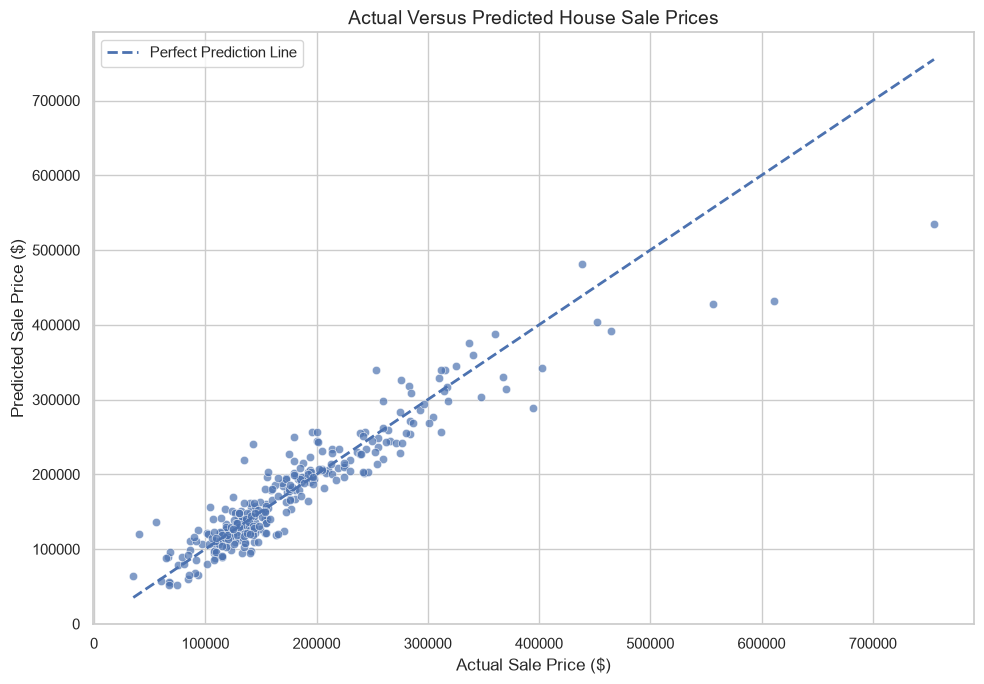

In [56]:
# Cell 70: Visualize Actual Versus Predicted Prices

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.7
)

minimum_price = min(
    y_test.min(),
    y_pred.min()
)

maximum_price = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction Line"
)

plt.title(
    "Actual Versus Predicted House Sale Prices",
    fontsize=14
)

plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.legend()

plt.tight_layout()
plt.show()

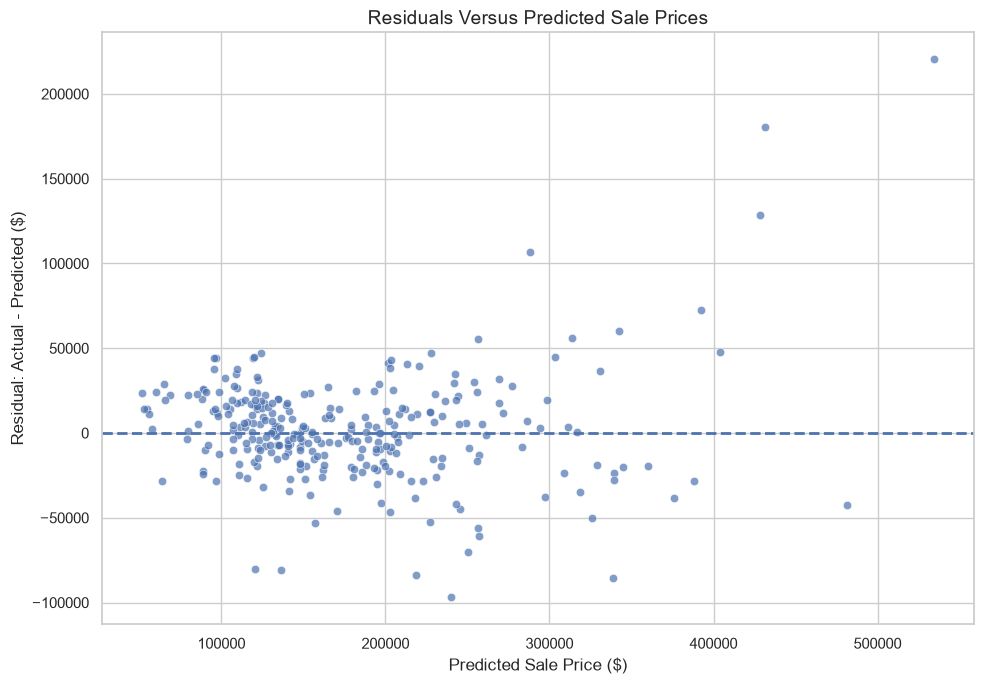

In [57]:
# Cell 71: Visualize Residuals Versus Predicted Prices

residuals = y_test - y_pred

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Residuals Versus Predicted Sale Prices",
    fontsize=14
)

plt.xlabel("Predicted Sale Price ($)")
plt.ylabel("Residual: Actual - Predicted ($)")

plt.tight_layout()
plt.show()

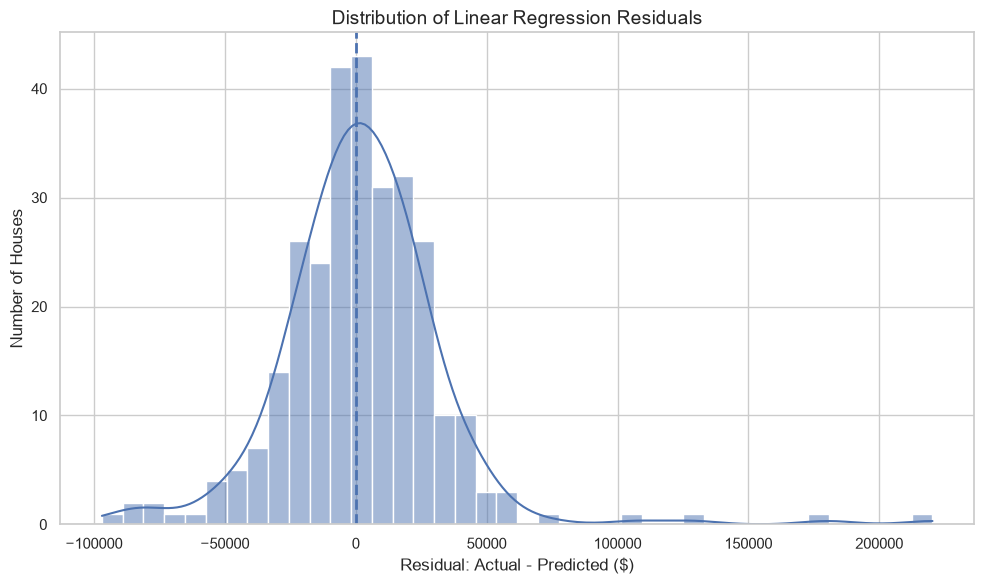

In [58]:
# Cell 72: Visualize the Residual Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Distribution of Linear Regression Residuals",
    fontsize=14
)

plt.xlabel("Residual: Actual - Predicted ($)")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.show()

# Cell 73: Baseline Linear Regression Findings

The Linear Regression model was trained using 80% of the housing records and
evaluated using the remaining 20%.

The model achieved:

- Mean Absolute Error: approximately $21,139.99
- Root Mean Squared Error: approximately $31,790.77
- R-squared score: 0.8682

Interpretation:

- The Mean Absolute Error represents the average absolute difference between
  actual and predicted sale prices.
- The Root Mean Squared Error gives more importance to large prediction errors.
- The R-squared score represents the proportion of test-set sale-price
  variation explained by the model.
- The actual-versus-predicted plot shows how closely predictions follow real
  prices.
- The residual plots help determine whether prediction errors are random or
  follow a systematic pattern.
- This is the baseline Linear Regression model and may later be compared with
  a log-target version.

# Cell 74: Mathematics of Linear Regression

Linear Regression predicts a numerical value by learning a linear relationship
between input features and the target variable.

## Simple Linear Regression

When there is only one input feature, the equation is:

$$
\hat{y} = b_0 + b_1x
$$

Where:

- $\hat{y}$ is the predicted value.
- $b_0$ is the intercept.
- $b_1$ is the coefficient or slope.
- $x$ is the input feature.

For example, if living area is the only input feature:

$$
\text{Predicted Price}
=
b_0 + b_1(\text{Living Area})
$$

## Multiple Linear Regression

Our housing dataset contains multiple input features. Therefore, the model uses:

$$
\hat{y}
=
b_0
+
b_1x_1
+
b_2x_2
+
\cdots
+
b_nx_n
$$

Where:

- $\hat{y}$ is the predicted house price.
- $b_0$ is the intercept.
- $b_1, b_2, \ldots, b_n$ are learned coefficients.
- $x_1, x_2, \ldots, x_n$ are house features.
- $n$ is the total number of processed input features.

## Simplified House-Price Example

Suppose a simplified model uses only living area and overall quality:

$$
\text{Predicted Price}
=
50{,}000
+
100(\text{Living Area})
+
20{,}000(\text{Overall Quality})
$$

For a house with:

- Living area = $1{,}500$ square feet
- Overall quality = $7$

The prediction is:

$$
\text{Predicted Price}
=
50{,}000
+
100(1{,}500)
+
20{,}000(7)
$$

$$
\text{Predicted Price}
=
50{,}000
+
150{,}000
+
140{,}000
$$

$$
\text{Predicted Price}
=
340{,}000
$$

Therefore, the predicted house price is **\$340,000**.

## Residual or Prediction Error

The residual is the difference between the actual price and predicted price:

$$
\text{Residual}
=
\text{Actual Price}
-
\text{Predicted Price}
$$

Suppose the actual sale price is **\$360,000**:

$$
\text{Residual}
=
360{,}000
-
340{,}000
$$

$$
\text{Residual}
=
20{,}000
$$

A positive residual means the model predicted a value lower than the actual
price. A negative residual means the model predicted a value higher than the
actual price.

Linear Regression learns its coefficients by minimizing the total squared
prediction errors across the training data.

In [59]:
# Cell 75: Manual Regression Error Calculation

actual_price = 360000
predicted_price = 340000

residual = actual_price - predicted_price
absolute_error = abs(residual)
squared_error = residual ** 2

print(f"Actual price: ${actual_price:,.2f}")
print(f"Predicted price: ${predicted_price:,.2f}")
print(f"Residual: ${residual:,.2f}")
print(f"Absolute error: ${absolute_error:,.2f}")
print(f"Squared error: {squared_error:,.2f} dollars²")

Actual price: $360,000.00
Predicted price: $340,000.00
Residual: $20,000.00
Absolute error: $20,000.00
Squared error: 400,000,000.00 dollars²


# Cell 76: Classification Extension

Accuracy, precision, recall, F1 score, confusion matrix, and confidence
probability are classification metrics.

They cannot correctly evaluate exact numerical house-price predictions.

To demonstrate these concepts correctly, a separate classification problem will
be created:

- Class 0: Sale price below the training-set median
- Class 1: Sale price equal to or above the training-set median

A Logistic Regression classifier will predict the price category and return a
probability-based confidence score.

In [60]:
# Cell 77: Create House Price Classification Labels

classification_threshold = y_train.median()

y_train_class = (
    y_train >= classification_threshold
).astype(int)

y_test_class = (
    y_test >= classification_threshold
).astype(int)

print(
    "Classification threshold:",
    f"${classification_threshold:,.2f}"
)

print("\nTraining-class distribution:")
print(y_train_class.value_counts().sort_index())

print("\nTesting-class distribution:")
print(y_test_class.value_counts().sort_index())

Classification threshold: $165,000.00

Training-class distribution:
SalePrice
0    582
1    586
Name: count, dtype: int64

Testing-class distribution:
SalePrice
0    162
1    130
Name: count, dtype: int64


In [61]:
# Cell 78: Build the Logistic Regression Classification Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

classification_median_pipeline = Pipeline(
    steps=[
        (
            "median_imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "standard_scaler",
            StandardScaler()
        )
    ]
)

classification_zero_pipeline = Pipeline(
    steps=[
        (
            "zero_imputer",
            SimpleImputer(
                strategy="constant",
                fill_value=0
            )
        ),
        (
            "standard_scaler",
            StandardScaler()
        )
    ]
)

classification_categorical_pipeline = Pipeline(
    steps=[
        (
            "categorical_imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "one_hot_encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

classification_preprocessor = ColumnTransformer(
    transformers=[
        (
            "median_numerical",
            classification_median_pipeline,
            median_imputation_columns
        ),
        (
            "zero_numerical",
            classification_zero_pipeline,
            zero_imputation_columns
        ),
        (
            "categorical",
            classification_categorical_pipeline,
            categorical_columns
        )
    ]
)

classification_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            classification_preprocessor
        ),
        (
            "logistic_regression",
            LogisticRegression(
                max_iter=5000,
                random_state=42
            )
        )
    ]
)

print("Classification pipeline created successfully.")

Classification pipeline created successfully.


In [62]:
# Cell 79: Train the House Price Classification Model

classification_pipeline.fit(
    X_train,
    y_train_class
)

y_class_pred = classification_pipeline.predict(
    X_test
)

y_class_probability = (
    classification_pipeline.predict_proba(X_test)
)

print("Classification model trained successfully.")
print("Number of class predictions:", len(y_class_pred))

Classification model trained successfully.
Number of class predictions: 292


c:\Users\Hp\Desktop\Housing Price prediction\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [14, 29] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\Hp\Desktop\Housing Price prediction\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [14, 29] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [63]:
# Cell 80: Calculate Classification Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(
    y_test_class,
    y_class_pred
)

precision = precision_score(
    y_test_class,
    y_class_pred
)

recall = recall_score(
    y_test_class,
    y_class_pred
)

f1 = f1_score(
    y_test_class,
    y_class_pred
)

classification_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ],
        "Score": [
            accuracy,
            precision,
            recall,
            f1
        ]
    }
)

classification_metrics["Score"] = (
    classification_metrics["Score"].round(4)
)

classification_metrics

,Metric,Score
0,Accuracy,0.9452
1,Precision,0.9254
2,Recall,0.9538
3,F1 Score,0.9394


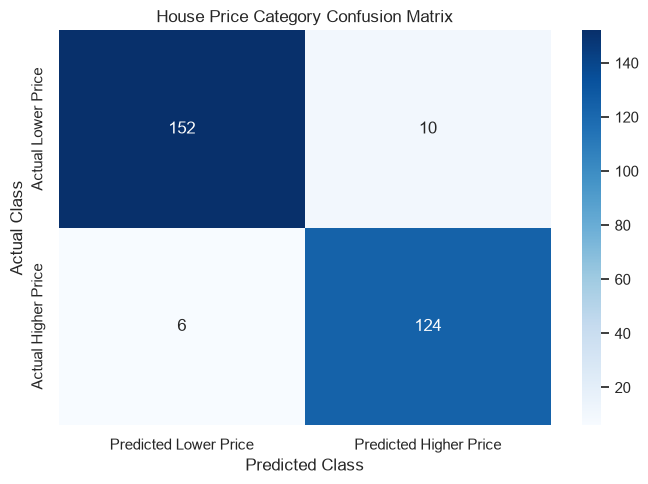

In [64]:
# Cell 81: Visualize the Confusion Matrix

confusion = confusion_matrix(
    y_test_class,
    y_class_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Lower Price",
        "Predicted Higher Price"
    ],
    yticklabels=[
        "Actual Lower Price",
        "Actual Higher Price"
    ]
)

plt.title("House Price Category Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

# Cell 82: Mathematics of Classification Metrics

The confusion matrix contains four possible outcomes.

- **True Positive (TP):** A higher-price house is correctly predicted as higher-price.
- **True Negative (TN):** A lower-price house is correctly predicted as lower-price.
- **False Positive (FP):** A lower-price house is incorrectly predicted as higher-price.
- **False Negative (FN):** A higher-price house is incorrectly predicted as lower-price.

For our model:

- TP = 124
- TN = 152
- FP = 10
- FN = 6

## Accuracy

Accuracy measures the proportion of all predictions that are correct.

$$
\text{Accuracy}
=
\frac{TP + TN}
{TP + TN + FP + FN}
$$

Using our confusion-matrix values:

$$
\text{Accuracy}
=
\frac{124 + 152}
{124 + 152 + 10 + 6}
$$

$$
\text{Accuracy}
=
\frac{276}{292}
=
0.9452
$$

Therefore, the model correctly classified approximately **94.52%** of all
test houses.

## Precision

Precision measures how many houses predicted as higher-price were actually
higher-price.

$$
\text{Precision}
=
\frac{TP}
{TP + FP}
$$

Using our values:

$$
\text{Precision}
=
\frac{124}
{124 + 10}
$$

$$
\text{Precision}
=
\frac{124}{134}
=
0.9254
$$

Therefore, approximately **92.54%** of the houses predicted as higher-price
were actually higher-price.

## Recall

Recall measures how many actual higher-price houses were correctly identified.

$$
\text{Recall}
=
\frac{TP}
{TP + FN}
$$

Using our values:

$$
\text{Recall}
=
\frac{124}
{124 + 6}
$$

$$
\text{Recall}
=
\frac{124}{130}
=
0.9538
$$

Therefore, the model identified approximately **95.38%** of all actual
higher-price houses.

## F1 Score

The F1 score combines precision and recall into one balanced measurement.

$$
F1
=
2
\times
\frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

Using our precision and recall:

$$
F1
=
2
\times
\frac{0.9254 \times 0.9538}
{0.9254 + 0.9538}
$$

$$
F1
\approx
0.9394
$$

Therefore, the model achieved an F1 score of approximately **93.94%**.

## Final Interpretation

- Accuracy evaluates overall correctness.
- Precision focuses on the reliability of higher-price predictions.
- Recall focuses on finding actual higher-price houses.
- F1 score balances precision and recall.
- These metrics evaluate the separate classification model, not the Linear
  Regression model that predicts exact house prices.

In [65]:
# Cell 83: Display Classification Predictions With Confidence

classification_results = pd.DataFrame(
    {
        "Actual_Class": y_test_class.values,
        "Predicted_Class": y_class_pred,
        "Probability_Lower_Price": (
            y_class_probability[:, 0]
        ),
        "Probability_Higher_Price": (
            y_class_probability[:, 1]
        )
    },
    index=y_test.index
)

classification_results["Confidence_Percentage"] = (
    classification_results[
        [
            "Probability_Lower_Price",
            "Probability_Higher_Price"
        ]
    ].max(axis=1) * 100
)

classification_results.head(10).round(4)

,Actual_Class,Predicted_Class,Probability_Lower_Price,Probability_Higher_Price,Confidence_Percentage
892,0,0,0.9637,0.0363,96.3690
1105,1,1,0.0000,1.0000,99.9961
413,0,0,0.9995,0.0005,99.9466
522,0,0,0.8775,0.1225,87.7522
1036,1,1,0.0004,0.9996,99.9578
614,0,0,0.9999,0.0001,99.9942
218,1,1,0.0009,0.9991,99.9063
1160,0,0,0.7627,0.2373,76.2699
649,0,0,1.0000,0.0000,99.9981
887,0,0,0.9017,0.0983,90.1717


In [66]:
# Cell 84: Create Default Values for User Input

default_house_values = {}

for column in X_train.columns:
    if column in numerical_columns:
        default_house_values[column] = (
            X_train[column].median()
        )
    else:
        available_mode = (
            X_train[column]
            .mode(dropna=True)
        )

        if len(available_mode) > 0:
            default_house_values[column] = (
                available_mode.iloc[0]
            )
        else:
            default_house_values[column] = np.nan

default_house = pd.DataFrame(
    [default_house_values],
    columns=X_train.columns
)

print("Default house template created.")
print("Number of input features:", default_house.shape[1])

Default house template created.
Number of input features: 79


In [67]:
# Cell 85: Interactive House Price Prediction Function

def read_numeric_input(message, minimum=None, maximum=None):
    while True:
        try:
            value = float(input(message))

            if minimum is not None and value < minimum:
                print(f"Value must be at least {minimum}.")
                continue

            if maximum is not None and value > maximum:
                print(f"Value must not exceed {maximum}.")
                continue

            return value

        except ValueError:
            print("Please enter a valid numerical value.")


def predict_new_house():
    new_house = default_house.copy()

    print("Enter the important characteristics of the house.\n")

    new_house.loc[0, "OverallQual"] = read_numeric_input(
        "Overall quality (1-10): ",
        minimum=1,
        maximum=10
    )

    new_house.loc[0, "GrLivArea"] = read_numeric_input(
        "Above-ground living area in square feet: ",
        minimum=1
    )

    new_house.loc[0, "YearBuilt"] = read_numeric_input(
        "Construction year: ",
        minimum=1800,
        maximum=2026
    )

    new_house.loc[0, "TotalBsmtSF"] = read_numeric_input(
        "Total basement area in square feet: ",
        minimum=0
    )

    new_house.loc[0, "GarageCars"] = read_numeric_input(
        "Garage capacity in cars: ",
        minimum=0
    )

    new_house.loc[0, "FullBath"] = read_numeric_input(
        "Number of full bathrooms: ",
        minimum=0
    )

    new_house.loc[0, "BedroomAbvGr"] = read_numeric_input(
        "Number of bedrooms above ground: ",
        minimum=0
    )

    valid_neighborhoods = sorted(
        X_train["Neighborhood"]
        .dropna()
        .unique()
    )

    print("\nAvailable neighborhoods:")
    print(", ".join(valid_neighborhoods))

    neighborhood_input = input(
        "\nEnter neighborhood exactly as shown: "
    ).strip()

    if neighborhood_input in valid_neighborhoods:
        new_house.loc[0, "Neighborhood"] = (
            neighborhood_input
        )
    else:
        default_neighborhood = (
            default_house.loc[0, "Neighborhood"]
        )

        print(
            "Neighborhood not recognized."
            f" Using default: {default_neighborhood}"
        )

    predicted_sale_price = (
        linear_regression_pipeline
        .predict(new_house)[0]
    )

    predicted_category = (
        classification_pipeline
        .predict(new_house)[0]
    )

    category_probabilities = (
        classification_pipeline
        .predict_proba(new_house)[0]
    )

    confidence_percentage = (
        category_probabilities.max() * 100
    )

    if predicted_category == 1:
        category_name = "Higher-price category"
    else:
        category_name = "Lower-price category"

    lower_estimate = max(
        0,
        predicted_sale_price - mae
    )

    upper_estimate = (
        predicted_sale_price + mae
    )

    print("\nPrediction Results")
    print("------------------")

    print(
        "Predicted sale price:",
        f"${predicted_sale_price:,.2f}"
    )

    print(
        "Approximate MAE-based range:",
        f"${lower_estimate:,.2f}",
        "to",
        f"${upper_estimate:,.2f}"
    )

    print("Predicted category:", category_name)

    print(
        "Classification confidence:",
        f"{confidence_percentage:.2f}%"
    )

In [68]:
# Cell 86: Run the Interactive Prediction System

predict_new_house()

Enter the important characteristics of the house.

Please enter a valid numerical value.
Please enter a valid numerical value.
Please enter a valid numerical value.
Please enter a valid numerical value.
Please enter a valid numerical value.
Please enter a valid numerical value.

Available neighborhoods:
Blmngtn, Blueste, BrDale, BrkSide, ClearCr, CollgCr, Crawfor, Edwards, Gilbert, IDOTRR, MeadowV, Mitchel, NAmes, NPkVill, NWAmes, NoRidge, NridgHt, OldTown, SWISU, Sawyer, SawyerW, Somerst, StoneBr, Timber, Veenker
Neighborhood not recognized. Using default: NAmes

Prediction Results
------------------
Predicted sale price: $830,800.12
Approximate MAE-based range: $809,660.13 to $851,940.11
Predicted category: Higher-price category
Classification confidence: 100.00%


In [69]:
# Cell 87: Save the Trained Models

import joblib

linear_model_file = (
    project_folder
    / "models"
    / "linear_regression_pipeline.joblib"
)

classification_model_file = (
    project_folder
    / "models"
    / "classification_pipeline.joblib"
)

joblib.dump(
    linear_regression_pipeline,
    linear_model_file
)

joblib.dump(
    classification_pipeline,
    classification_model_file
)

print("Linear Regression model saved to:")
print(linear_model_file)

print("\nClassification model saved to:")
print(classification_model_file)

Linear Regression model saved to:
c:\Users\Hp\Desktop\Housing Price prediction\models\linear_regression_pipeline.joblib

Classification model saved to:
c:\Users\Hp\Desktop\Housing Price prediction\models\classification_pipeline.joblib


# Cell 88: Final Verified Machine-Learning Pipeline

The completed project follows this pipeline:

1. Define the house-price prediction problem
2. Load the original uncleaned housing dataset
3. Inspect rows, columns, features, and target
4. Identify numerical and categorical variables
5. Analyze missing values
6. Check duplicate records
7. Check invalid and suspicious values
8. Analyze the target distribution
9. Visualize important numerical distributions and outliers
10. Separate input features and target
11. Split the dataset into training and testing sets
12. Learn preprocessing only from training data
13. Impute missing numerical and categorical values
14. One-hot encode categorical features
15. Train a Linear Regression model
16. Generate predictions for unseen test houses
17. Evaluate using MAE, MSE, RMSE, and R-squared
18. Analyze actual-versus-predicted prices and residuals
19. Train a separate classification model
20. Evaluate classification using confusion matrix, accuracy, precision, recall,
    and F1 score
21. Produce a probability-based classification confidence score
22. Accept user input and predict a new house price
23. Save the complete trained pipelines